In [1]:
import pickle as pkl
import sys

import arviz as az
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns

sys.path.insert(0, "/home/mahdi/python_projects/slim_development/")
from slim_development.behavioral_utils import (
    _entropy,
    _jsd_avg,
    calculate_MLE,
    get_sequence,
)

mpl.rcParams["text.usetex"] = True

sns.set(style="whitegrid", context="talk")

ibm_palette = [
    "#648fff",
    "#dc267f",
    "#fe6100",
    "#ffb000",
    "#785ef0",
    "#8be04e",
    "#009e73",
    "#56b4e9",
]
sns.set_palette(ibm_palette)

# %autoreload 2

In [2]:
az.rcParams["stats.ci_prob"] = 0.95

def display_results(x_idata):
    display(
        az.summary(
            x_idata,
            var_names=[
                "alpha",
                "beta_x",
                "beta_condition",
                "beta_interaction",
                "sigma",
                "sigma_participant",
            ],
            hdi_prob=0.95,
        )
    )

---

# Load and Prepare Data

In [3]:
seed = 1111

In [4]:
# with open("./stats/data_store.pkl", "rb") as f:
with open("./stats/data_store_with_hitrates.pkl", "rb") as f:
    data_store = pkl.load(f)
print(data_store.keys())

dict_keys(['behavioral_experiment1', 'behavioral_experiment2', 'model_experiment2', 'model_experiment1'])


In [5]:
behavioral_experiment1_dPrime_exp = np.array(list(data_store["behavioral_experiment1"]["all_dPrime_exp_experiment1_blockwise"].values()))
behavioral_experiment1_dPrime_une = np.array(list(data_store["behavioral_experiment1"]["all_dPrime_une_experiment1_blockwise"].values()))
behavioral_experiment1_dPrime_exp.shape, behavioral_experiment1_dPrime_une.shape
behavioral_experiment1_rt_exp = np.array(list(data_store["behavioral_experiment1"]["all_rt_exp_experiment1_blockwise"].values()))
behavioral_experiment1_rt_une = np.array(list(data_store["behavioral_experiment1"]["all_rt_une_experiment1_blockwise"].values()))
model_experiment1_belief_exp1 = np.array(list(data_store["model_experiment1"]["all_belief_exp1_model_blockwise"].values()))
model_experiment1_belief_exp2 = np.array(list(data_store["model_experiment1"]["all_belief_exp2_model_blockwise"].values()))
model_experiment1_belief_une1 = np.array(list(data_store["model_experiment1"]["all_belief_une1_model_blockwise"].values()))
model_experiment1_belief_une2 = np.array(list(data_store["model_experiment1"]["all_belief_une2_model_blockwise"].values()))
all_log_ratios_exp_model_blockwise = data_store["model_experiment1"]["all_log_ratios_exp_model_blockwise"]
all_log_ratios_une_model_blockwise = data_store["model_experiment1"]["all_log_ratios_une_model_blockwise"]
all_nlprior_exp_model_blockwise = data_store["model_experiment1"]["all_model_neglog_pred_exp_blockwise"]
all_nlprior_une_model_blockwise = data_store["model_experiment1"]["all_model_neglog_pred_une_blockwise"]
all_nlposterior_exp_model_blockwise = data_store["model_experiment1"]["all_model_neglog_post_exp_blockwise"]
all_nlposterior_une_model_blockwise = data_store["model_experiment1"]["all_model_neglog_post_une_blockwise"]
all_priorentropies_exp_model_blockwise = data_store["model_experiment1"]["all_priorentropies_exp_model_blockwise"]
all_priorentropies_une_model_blockwise = data_store["model_experiment1"]["all_priorentropies_une_model_blockwise"]
model_experiment1_dPrime_exp = np.array(list(data_store["model_experiment1"]["all_dPrime_exp_experiment1_blockwise"].values()))
model_experiment1_dPrime_une = np.array(list(data_store["model_experiment1"]["all_dPrime_une_experiment1_blockwise"].values()))
model_experiment1_surprize_exp = np.array(list(data_store["model_experiment1"]["all_surprize_exp_model_blockwise"].values()))
model_experiment1_surprize_une = np.array(list(data_store["model_experiment1"]["all_surprize_une_model_blockwise"].values()))

In [6]:

# KL(pred || obs)
model_experiment1_exp_pred_obs = []
model_experiment1_une_pred_obs = []
# shannon information
model_experiment1_exp_shannonI = []
model_experiment1_une_shannonI = []
# log ratio
model_experiment1_exp_log_ratio = []
model_experiment1_une_log_ratio = []
# entropy
model_experiment1_exp_entropies = []
model_experiment1_une_entropies = []

for block in range(11):
    model_experiment1_exp_pred_obs.append([])
    model_experiment1_une_pred_obs.append([])
    model_experiment1_exp_log_ratio.append([])
    model_experiment1_une_log_ratio.append([])
    model_experiment1_exp_entropies.append([])
    model_experiment1_une_entropies.append([])
    model_experiment1_exp_shannonI.append([])
    model_experiment1_une_shannonI.append([])

    for sid in range(36):
        model_experiment1_exp_log_ratio[block].append(all_log_ratios_exp_model_blockwise[block][sid])
        model_experiment1_une_log_ratio[block].append(all_log_ratios_une_model_blockwise[block][sid])
        model_experiment1_exp_entropies[block].append(np.mean([_entropy(model_experiment1_belief_exp1[block][sid]), _entropy(model_experiment1_belief_exp2[block][sid]),]))
        model_experiment1_une_entropies[block].append(np.mean([_entropy(model_experiment1_belief_une1[block][sid]), _entropy(model_experiment1_belief_une2[block][sid]),]))
        model_experiment1_exp_shannonI[block].append(np.mean([-np.log(np.max(model_experiment1_belief_exp1[block][sid])), -np.log(np.max(model_experiment1_belief_exp2[block][sid])),]))
        model_experiment1_une_shannonI[block].append(np.mean([-np.log(np.max(model_experiment1_belief_une1[block][sid])), -np.log(np.max(model_experiment1_belief_une2[block][sid])),]))

model_experiment1_exp_pred_obs = np.array(model_experiment1_exp_pred_obs)
model_experiment1_une_pred_obs = np.array(model_experiment1_une_pred_obs)
model_experiment1_exp_log_ratio = np.array(model_experiment1_exp_log_ratio)
model_experiment1_une_log_ratio = np.array(model_experiment1_une_log_ratio)
model_experiment1_exp_entropies = np.array(model_experiment1_exp_entropies)
model_experiment1_une_entropies = np.array(model_experiment1_une_entropies)
model_experiment1_exp_shannonI = np.array(model_experiment1_exp_shannonI)
model_experiment1_une_shannonI = np.array(model_experiment1_une_shannonI)

---

# Construct and Fit Bayesian Regression Models

In [7]:
n_participants = 36

df = pd.DataFrame(
    {
        "participant": np.tile(np.arange(n_participants), 11 * 2),
        "x_block": np.concatenate([np.repeat(np.arange(11), n_participants), np.repeat(np.arange(11), n_participants),]),
        "x_condition": np.concatenate([np.repeat([-0.5], n_participants * 11), np.repeat([0.5], n_participants * 11),]),
        "x_bayesian_surprize": np.concatenate([model_experiment1_surprize_exp.ravel(), model_experiment1_surprize_une.ravel()]),
        "x_log_ratio": np.concatenate([model_experiment1_exp_log_ratio.ravel(), model_experiment1_une_log_ratio.ravel()]),
        "x_neglog_prior": np.concatenate([np.array(list(all_nlprior_exp_model_blockwise.values())).ravel(), np.array(list(all_nlprior_une_model_blockwise.values())).ravel(),]),
        "x_neglog_posterior": np.concatenate([np.array(list(all_nlposterior_exp_model_blockwise.values())).ravel(), np.array(list(all_nlposterior_une_model_blockwise.values())).ravel(),]),
        "x_H_posterior": np.concatenate([model_experiment1_exp_entropies.ravel(), model_experiment1_une_entropies.ravel()]),
        "y": np.concatenate([behavioral_experiment1_dPrime_exp.ravel(), behavioral_experiment1_dPrime_une.ravel()]),
    }
)

print(df.shape)
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(
    subset=[
        "x_condition",
        "x_block",
        "x_bayesian_surprize",
        "x_log_ratio",
        "x_neglog_prior",
        "x_neglog_posterior",
        "x_H_posterior",
        "y",
    ]
)
print(df.shape)

df["y_z"] = (df["y"] - df["y"].mean()) / df["y"].std()
df["x_condition_z"] = (df["x_condition"] - df["x_condition"].mean()) / df["x_condition"].std()
df["x_block_z"] = (df["x_block"] - df["x_block"].mean()) / df["x_block"].std()
df["x_bayesian_surprize_z"] = (df["x_bayesian_surprize"] - df["x_bayesian_surprize"].mean()) / df["x_bayesian_surprize"].std()
df["x_log_ratio_z"] = (df["x_log_ratio"] - df["x_log_ratio"].mean()) / df["x_log_ratio"].std()
df["x_neglog_prior_z"] = (df["x_neglog_prior"] - df["x_neglog_prior"].mean()) / df["x_neglog_prior"].std()
df["x_neglog_posterior_z"] = (df["x_neglog_posterior"] - df["x_neglog_posterior"].mean()) / df["x_neglog_posterior"].std()
df["x_H_posterior_z"] = (df["x_H_posterior"] - df["x_H_posterior"].mean()) / df["x_H_posterior"].std()

participant_idx = df["participant"].to_numpy()
n_participants = df["participant"].nunique()

# z scored
x_condition = df["x_condition_z"].to_numpy()
x_block = df["x_block_z"].to_numpy()
x_bayesian_surprize = df["x_bayesian_surprize_z"].to_numpy()
x_log_ratio = df["x_log_ratio_z"].to_numpy()
x_neglog_prior = df["x_neglog_prior_z"].to_numpy()
x_neglog_posterior = df["x_neglog_posterior_z"].to_numpy()
x_H_posterior = df["x_H_posterior_z"].to_numpy()

y = df["y"].to_numpy()

df.head()

(792, 9)
(786, 9)


,participant,x_block,x_condition,x_bayesian_surprize,x_log_ratio,x_neglog_prior,x_neglog_posterior,x_H_posterior,y,y_z,x_condition_z,x_block_z,x_bayesian_surprize_z,x_log_ratio_z,x_neglog_prior_z,x_neglog_posterior_z,x_H_posterior_z
0,0,0,-0.5,1.092769,2.394783,1.869609,0.412897,0.899360,2.972148,1.963604,-0.991764,-1.573328,0.082016,0.302949,-0.285408,-0.446309,-0.001482
1,1,0,-0.5,1.070907,2.115444,1.886607,0.463773,0.948287,1.518106,-0.165389,-0.991764,-1.573328,0.050201,-0.077817,-0.272922,-0.211064,0.228591
2,2,0,-0.5,1.130515,2.430046,1.853096,0.397422,0.887699,2.633596,1.467899,-0.991764,-1.573328,0.136943,0.351015,-0.297536,-0.517864,-0.056315
3,3,0,-0.5,1.079568,2.526386,1.838149,0.380787,0.877405,3.439874,2.648443,-0.991764,-1.573328,0.062805,0.482335,-0.308515,-0.594780,-0.104719
4,4,0,-0.5,1.109641,2.368747,1.870422,0.413921,0.899118,2.635918,1.471300,-0.991764,-1.573328,0.106567,0.267458,-0.284810,-0.441575,-0.002620


In [10]:
predictor_names = ["bayesian surprize", "log ratio", "neglog_prior", "neglog_posterior", "H_posterior"]
predictors = [x_bayesian_surprize, x_log_ratio, x_neglog_prior, x_neglog_posterior, x_H_posterior]
idata_predictors = {}

for predictor_name, x_predictor in zip(predictor_names, predictors):
    with pm.Model() as model:
        alpha = pm.Normal("alpha", 0, 1)
        sigma_participant = pm.HalfNormal("sigma_participant", 1)
        a_participant = pm.Normal(
            "a_participant", 0, sigma_participant, shape=n_participants
        )
        beta_x = pm.Normal("beta_x", 0, 1)
        beta_condition = pm.Normal("beta_condition", 0, 1)
        beta_interaction = pm.Normal("beta_interaction", 0, 1)
        mu = (
            alpha
            + a_participant[participant_idx]  # subject level intercept
            + beta_condition * x_condition  # condition effect
            + beta_x * x_predictor  # predictor effect
            + beta_interaction * x_condition * x_predictor  # interaction
        )
        sigma = pm.HalfNormal("sigma", 1)
        pm.Normal("y", mu=mu, sigma=sigma, observed=y)
        idata_predictors[predictor_name] = pm.sample(
            target_accept=0.95,
            return_inferencedata=True,
            idata_kwargs={"log_likelihood": True},
            random_seed=seed,
        )

        pm.sample_posterior_predictive(
            idata_predictors[predictor_name],
            extend_inferencedata=True,
            random_seed=seed,
        )
    display_results(idata_predictors[predictor_name])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, sigma_participant, a_participant, beta_x, beta_condition, beta_interaction, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.
Sampling: [y]


Output()

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.874,0.080,1.704,2.021,0.003,0.002,818.0,1233.0,1.0
beta_x,0.107,0.044,0.020,0.190,0.001,0.001,3461.0,3022.0,1.0
beta_condition,-0.288,0.043,-0.375,-0.205,0.001,0.001,3549.0,3018.0,1.0
beta_interaction,-0.282,0.043,-0.360,-0.194,0.001,0.001,4710.0,2869.0,1.0
sigma,0.516,0.014,0.490,0.542,0.000,0.000,4403.0,2803.0,1.0
sigma_participant,0.408,0.054,0.310,0.518,0.001,0.001,4568.0,3171.0,1.0


...

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, sigma_participant, a_participant, beta_x, beta_condition, beta_interaction, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.
Sampling: [y]


Output()

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.722,0.073,1.575,1.863,0.003,0.002,491.0,947.0,1.01
beta_x,0.192,0.044,0.106,0.279,0.001,0.001,1929.0,2064.0,1.00
beta_condition,-0.315,0.033,-0.380,-0.250,0.001,0.001,2125.0,2638.0,1.00
beta_interaction,-0.166,0.044,-0.245,-0.073,0.001,0.001,2219.0,2430.0,1.00
sigma,0.524,0.014,0.498,0.551,0.000,0.000,4115.0,3335.0,1.00
sigma_participant,0.408,0.054,0.313,0.514,0.001,0.001,3380.0,3039.0,1.00


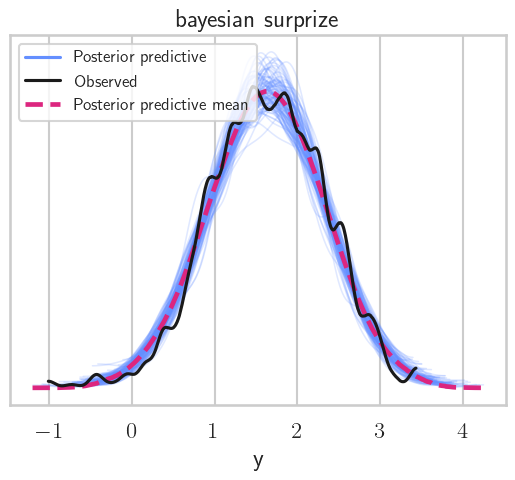

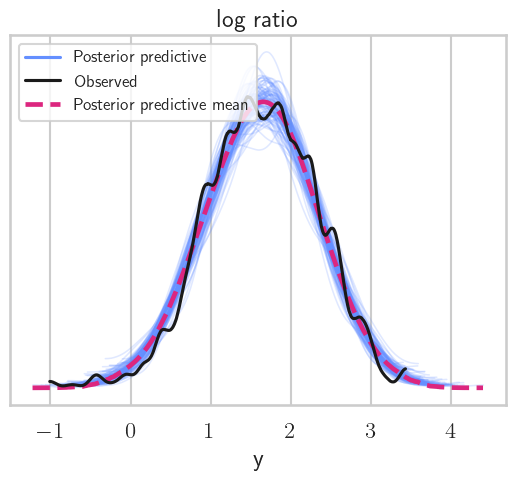

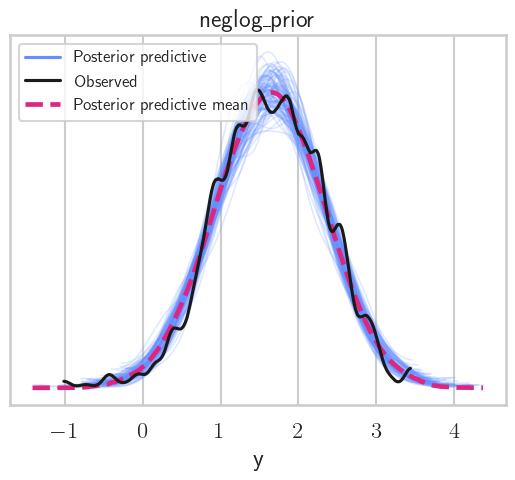

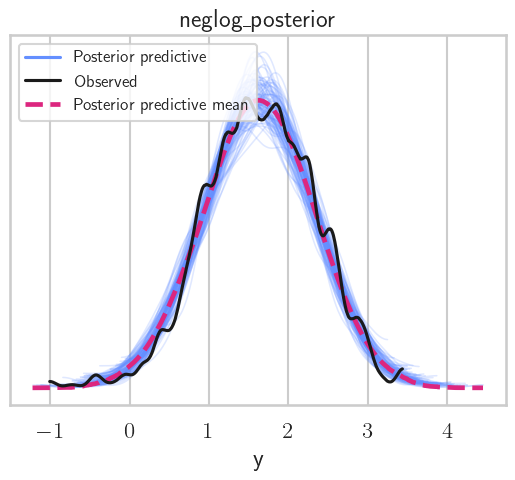

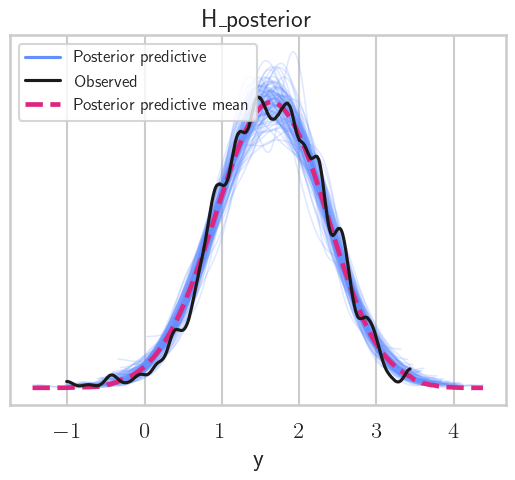

In [12]:
for name, idata in idata_predictors.items():
    az.plot_ppc(idata, num_pp_samples=100)
    plt.title(name)
    plt.show()

In [21]:
for name, idata in idata_predictors.items():
    bpval_overall = (idata.posterior_predictive["y"] > idata.observed_data["y"]).mean().values
    print(f"{name}: Bayesian p-value: {bpval_overall.mean():.3f}")

bayesian surprize: Bayesian p-value: 0.494
log ratio: Bayesian p-value: 0.495
neglog_prior: Bayesian p-value: 0.494
neglog_posterior: Bayesian p-value: 0.494
H_posterior: Bayesian p-value: 0.494


In [11]:
compare_df = az.compare(idata_predictors, ic="loo")
compare_df

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
neglog_prior,0,-610.807380,37.902663,0.000000,0.735704,26.074865,0.000000,False,log
bayesian surprize,1,-614.384320,38.240596,3.576941,0.151848,25.777023,3.827168,False,log
H_posterior,2,-625.699667,37.603146,14.892287,0.000000,24.837303,5.827519,False,log
neglog_posterior,3,-628.283159,37.527045,17.475780,0.000000,24.528926,6.276512,False,log
log ratio,4,-629.370184,37.436651,18.562804,0.112449,24.124441,7.264095,False,log


In [12]:
compare_df.to_latex(
    # "model_comparison.tex",
    float_format="%.3f",
    caption="LOO model comparison",
    label="tab:model_comparison",
)

'\\begin{table}\n\\caption{LOO model comparison}\n\\label{tab:model_comparison}\n\\begin{tabular}{lrrrrrrrrl}\n\\toprule\n & rank & elpd_loo & p_loo & elpd_diff & weight & se & dse & warning & scale \\\\\n\\midrule\nneglog_prior & 0 & -610.807 & 37.903 & 0.000 & 0.736 & 26.075 & 0.000 & False & log \\\\\nbayesian surprize & 1 & -614.384 & 38.241 & 3.577 & 0.152 & 25.777 & 3.827 & False & log \\\\\nH_posterior & 2 & -625.700 & 37.603 & 14.892 & 0.000 & 24.837 & 5.828 & False & log \\\\\nneglog_posterior & 3 & -628.283 & 37.527 & 17.476 & 0.000 & 24.529 & 6.277 & False & log \\\\\nlog ratio & 4 & -629.370 & 37.437 & 18.563 & 0.112 & 24.124 & 7.264 & False & log \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

## Winner Model

In [13]:
print("neglog_prior")
with pm.Model() as model:
    alpha = pm.Normal("alpha", 0, 1)
    sigma_participant = pm.HalfNormal("sigma_participant", 1)
    a_participant = pm.Normal(
        "a_participant", 0, sigma_participant, shape=n_participants
    )
    beta_x = pm.Normal("beta_x", 0, 1)
    beta_condition = pm.Normal("beta_condition", 0, 1)
    beta_interaction = pm.Normal("beta_interaction", 0, 1)
    mu = (
        alpha
        + a_participant[participant_idx]
        + beta_condition * x_condition
        + beta_x * x_neglog_prior
        + beta_interaction * x_condition * x_neglog_prior
    )
    sigma = pm.HalfNormal("sigma", 1)
    pm.Normal("y", mu=mu, sigma=sigma, observed=y)
    idata_x_neglog_prior = pm.sample(
        target_accept=0.95,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True},
        random_seed=seed,
    )
df_results = az.summary(
    idata_x_neglog_prior,
    var_names=[
        "alpha",
        "beta_x",
        "beta_condition",
        "beta_interaction",
        "sigma",
        "sigma_participant",
    ],
    hdi_prob=0.95,
)
display(df_results)

df_results.to_latex(
    # "model_comparison.tex",
    float_format="%.3f",
    caption="LOO model comparison",
    label="tab:model_comparison",
)

neglog_prior


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, sigma_participant, a_participant, beta_x, beta_condition, beta_interaction, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,2.013,0.089,1.839,2.187,0.003,0.002,817.0,1304.0,1.0
beta_x,0.186,0.061,0.071,0.309,0.001,0.001,3018.0,3052.0,1.0
beta_condition,-0.365,0.060,-0.483,-0.253,0.001,0.001,3081.0,3169.0,1.0
beta_interaction,-0.420,0.059,-0.538,-0.305,0.001,0.001,3424.0,3032.0,1.0
sigma,0.514,0.014,0.486,0.539,0.000,0.000,6537.0,3155.0,1.0
sigma_participant,0.406,0.052,0.311,0.510,0.001,0.001,5105.0,3082.0,1.0


'\\begin{table}\n\\caption{LOO model comparison}\n\\label{tab:model_comparison}\n\\begin{tabular}{lrrrrrrrrr}\n\\toprule\n & mean & sd & hdi_2.5% & hdi_97.5% & mcse_mean & mcse_sd & ess_bulk & ess_tail & r_hat \\\\\n\\midrule\nalpha & 2.013 & 0.089 & 1.839 & 2.187 & 0.003 & 0.002 & 817.000 & 1304.000 & 1.000 \\\\\nbeta_x & 0.186 & 0.061 & 0.071 & 0.309 & 0.001 & 0.001 & 3018.000 & 3052.000 & 1.000 \\\\\nbeta_condition & -0.365 & 0.060 & -0.483 & -0.253 & 0.001 & 0.001 & 3081.000 & 3169.000 & 1.000 \\\\\nbeta_interaction & -0.420 & 0.059 & -0.538 & -0.305 & 0.001 & 0.001 & 3424.000 & 3032.000 & 1.000 \\\\\nsigma & 0.514 & 0.014 & 0.486 & 0.539 & 0.000 & 0.000 & 6537.000 & 3155.000 & 1.000 \\\\\nsigma_participant & 0.406 & 0.052 & 0.311 & 0.510 & 0.001 & 0.001 & 5105.000 & 3082.000 & 1.000 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

## Simple Effects

In [14]:
cond1 = x_condition[x_condition < 0][0]
cond2 = x_condition[x_condition > 0][0]

posterior = idata_x_neglog_prior.posterior

slope_cond1 = posterior["beta_x"] + cond1 * posterior["beta_interaction"]
slope_cond2 = posterior["beta_x"] + cond2 * posterior["beta_interaction"]
df_summary = az.summary(
    {"expected": slope_cond1, "unexpected": slope_cond2}, hdi_prob=0.95
)
display(df_summary)
df_summary.to_latex(
    # "model_comparison.tex",
    float_format="%.3f",
    caption="Regression Coefficients of Winning Model",
    label="tab:winner_model",
)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
expected,0.603,0.105,0.403,0.811,0.002,0.001,2639.0,2819.0,1.0
unexpected,-0.237,0.059,-0.356,-0.124,0.001,0.001,9565.0,2904.0,1.0


'\\begin{table}\n\\caption{Regression Coefficients of Winning Model}\n\\label{tab:winner_model}\n\\begin{tabular}{lrrrrrrrrr}\n\\toprule\n & mean & sd & hdi_2.5% & hdi_97.5% & mcse_mean & mcse_sd & ess_bulk & ess_tail & r_hat \\\\\n\\midrule\nexpected & 0.603 & 0.105 & 0.403 & 0.811 & 0.002 & 0.001 & 2639.000 & 2819.000 & 1.000 \\\\\nunexpected & -0.237 & 0.059 & -0.356 & -0.124 & 0.001 & 0.001 & 9565.000 & 2904.000 & 1.000 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

/tmp/ipykernel_4030070/3570903772.py:24: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_expected = az.hdi(mu_expected, hdi_prob=0.95)
/tmp/ipykernel_4030070/3570903772.py:25: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_unexpected = az.hdi(mu_unexpected, hdi_prob=0.95)


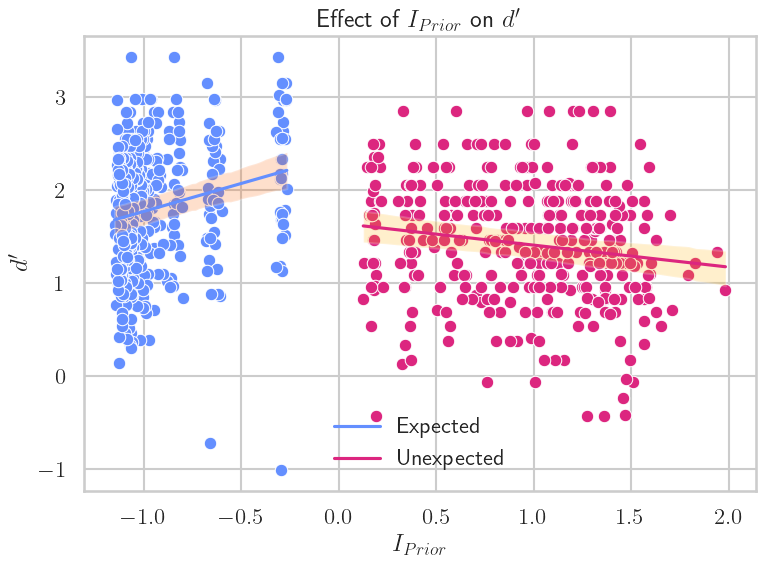

In [15]:
x_grid_expected = np.linspace(df.x_neglog_prior_z[x_condition<0].min(), df.x_neglog_prior_z[x_condition<0].max())
x_grid_unexpected = np.linspace(df.x_neglog_prior_z[x_condition>0].min(), df.x_neglog_prior_z[x_condition>0].max())
alpha = posterior["alpha"].values.reshape(-1)
beta_condition = posterior["beta_condition"].values.reshape(-1)
beta_neglog_prior = posterior["beta_x"].values.reshape(-1)
beta_interaction = posterior["beta_interaction"].values.reshape(-1)


def predicted_mu(condition_value, grid):
    return (
        alpha[:, None]
        + beta_condition[:, None] * condition_value
        + beta_neglog_prior[:, None] * grid[None, :]
        + beta_interaction[:, None] * condition_value * grid[None, :]
    )


mu_expected = predicted_mu(cond1, x_grid_expected)
mu_unexpected = predicted_mu(cond2, x_grid_unexpected)

mean_expected = mu_expected.mean(axis=0)
mean_unexpected = mu_unexpected.mean(axis=0)

hdi_expected = az.hdi(mu_expected, hdi_prob=0.95)
hdi_unexpected = az.hdi(mu_unexpected, hdi_prob=0.95)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=df.x_neglog_prior_z[df.x_condition == -0.5],
    y=df.y[df.x_condition == -0.5],
    # label="expected",
)
sns.scatterplot(
    x=df.x_neglog_prior_z[df.x_condition == 0.5],
    y=df.y[df.x_condition == .5],
    # label="unexpected",
)

plt.plot(x_grid_expected, mean_expected, label="Expected")
plt.fill_between(x_grid_expected, hdi_expected[:, 0], hdi_expected[:, 1], alpha=0.2)

plt.plot(x_grid_unexpected, mean_unexpected, label="Unexpected")
plt.fill_between(x_grid_unexpected, hdi_unexpected[:, 0], hdi_unexpected[:, 1], alpha=0.2)
plt.xlabel("$I_{Prior}$")
plt.ylabel("$d'$")
plt.legend(frameon=False)
plt.title("Effect of $I_{Prior}$ on $d'$")
plt.tight_layout()
plt.savefig("./figures/bayesian_regression_experiment1_dprime.png", dpi=300)
plt.show()

/tmp/ipykernel_4030070/2430707542.py:139: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_expected = az.hdi(mu_expected, hdi_prob=0.95)
/tmp/ipykernel_4030070/2430707542.py:140: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_unexpected = az.hdi(mu_unexpected, hdi_prob=0.95)


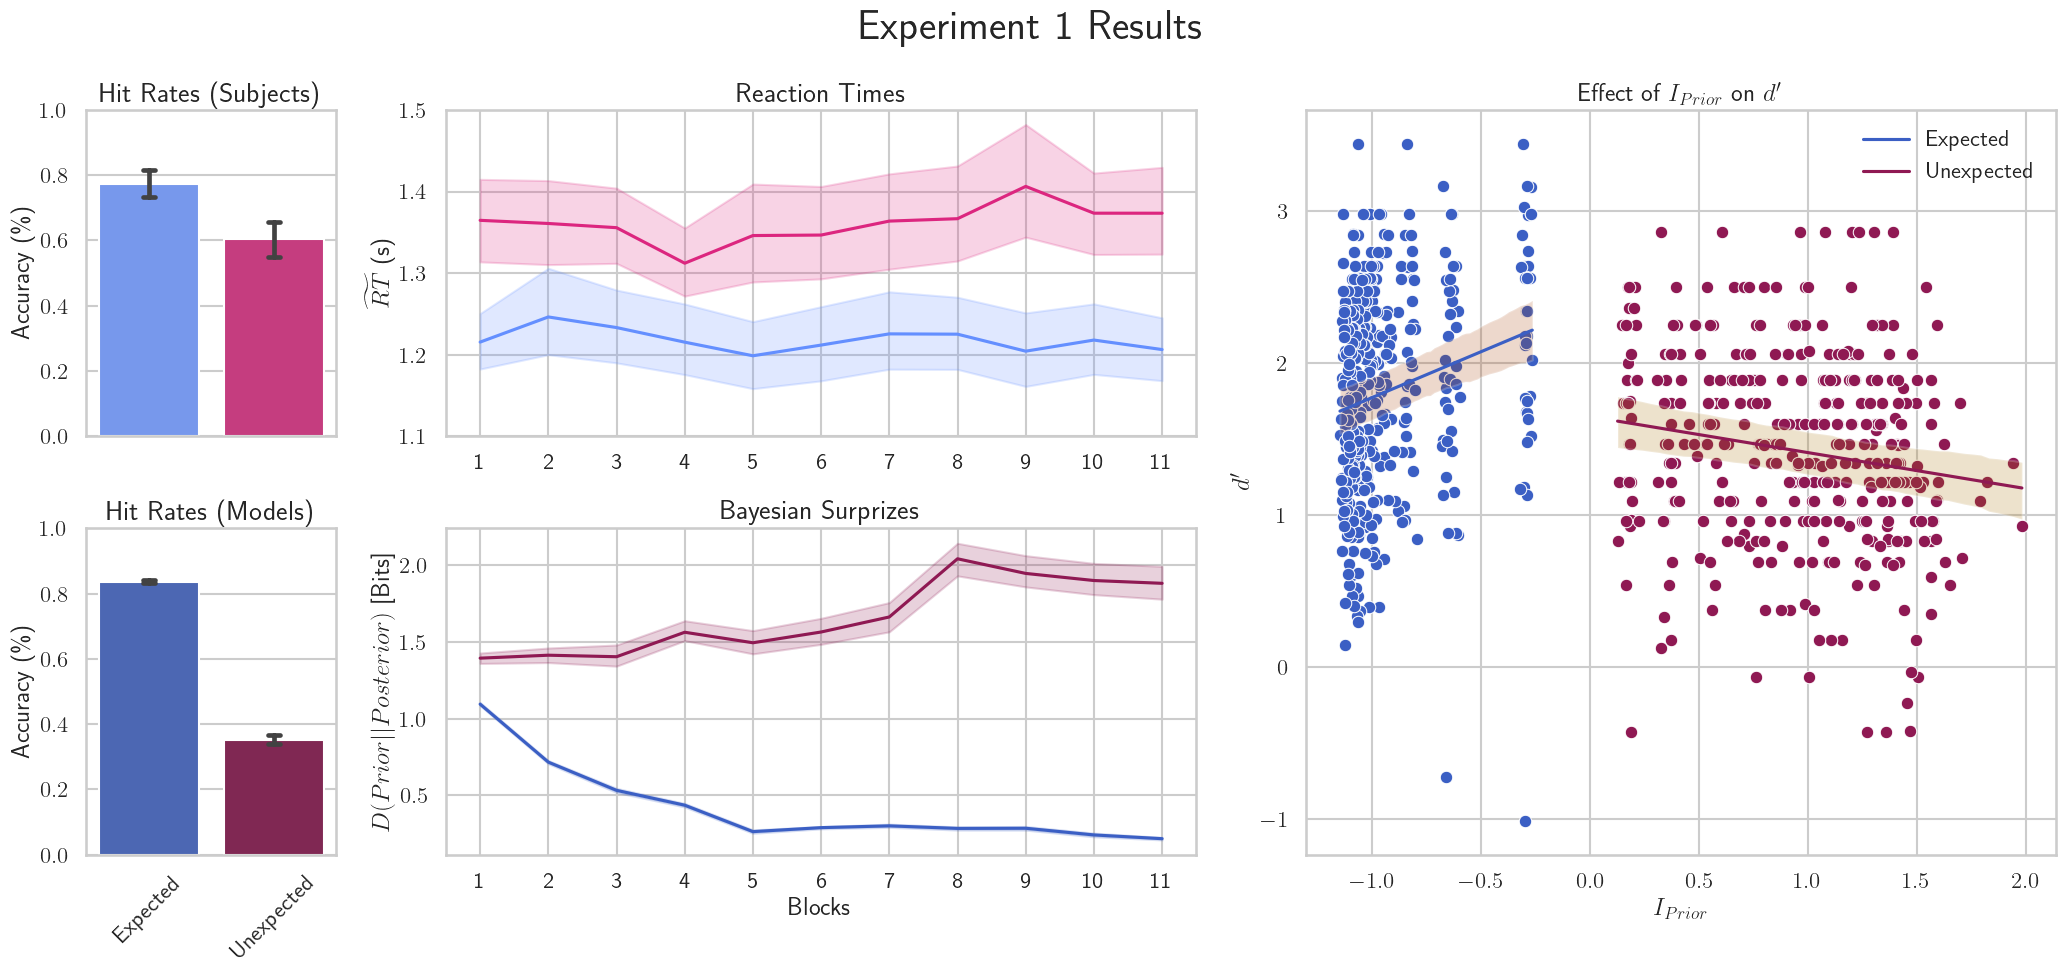

In [16]:
# plot next to other results
# with open("./stats/data_store_with_hitrates.pkl", "rb") as f:
#     data_store = pkl.load(f)
# print(data_store.keys())

all_acc_exp_experiment1 = data_store['behavioral_experiment1']['all_acc_exp_experiment1']
all_acc_une_experiment1 = data_store['behavioral_experiment1']['all_acc_une_experiment1']

all_rt_exp_experiment1_blockwise = data_store['behavioral_experiment1']['all_rt_exp_experiment1_blockwise']
all_rt_une_experiment1_blockwise = data_store['behavioral_experiment1']['all_rt_une_experiment1_blockwise']

all_acc_exp_model = data_store['model_experiment1']['all_acc_exp_experiment1']
all_acc_une_model = data_store['model_experiment1']['all_acc_une_experiment1']

all_surprize_exp_model_blockwise = data_store['model_experiment1']['all_surprize_exp_model_blockwise']
all_surprize_une_model_blockwise = data_store['model_experiment1']['all_surprize_une_model_blockwise']


ibm_palette = ["#648fff", "#dc267f", "#fe6100", "#ffb000", "#785ef0", "#8be04e", "#009e73", "#56b4e9",]
ibm_palette_darker = ["#3b5fc4", "#8f1953", "#a63f00", "#a86f00", "#4a37b8", "#8be04e", "#009e73", "#56b4e9",]


fig = plt.figure(figsize=(21, 10))
gs = fig.add_gridspec(2, 3, width_ratios=[1, 3, 3], height_ratios=[1, 1])
ax0 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

sns.set_palette(ibm_palette)
df_results = pd.DataFrame(
    np.array([all_acc_exp_experiment1, all_acc_une_experiment1]).T,
    columns=["Expected", "Unexpected"],
)
sns.barplot(df_results, ax=ax0, errorbar=("ci", 95), capsize=0.1)  # 95% confience interval
ax0.set_title("Hit Rates (Subjects)", fontweight="bold", fontsize=20)
ax0.set_ylabel(r"Accuracy (\%)")
ax0.set_ylim(0, 1)
ax0.set_xticks([])


# rts/surprizes
sns.set_palette(ibm_palette)
sns.lineplot(
    data=(
        pd.DataFrame(all_rt_exp_experiment1_blockwise)
        .T.assign(x=np.arange(len(all_rt_exp_experiment1_blockwise)))
        .melt(id_vars="x", value_name="y")
    ),
    x="x",
    y="y",
    errorbar=("ci", 95),
    ax=ax2,
)
sns.lineplot(
    data=(
        pd.DataFrame(all_rt_une_experiment1_blockwise)
        .T.assign(x=np.arange(len(all_rt_une_experiment1_blockwise)))
        .melt(id_vars="x", value_name="y")
    ),
    x="x",
    y="y",
    errorbar=("ci", 95),
    ax=ax2,
)
ax2.set_title(r"Reaction Times", fontweight="bold", fontsize=20)
ax2.set_ylabel(r"$\widetilde{RT}$ (s)")
ax2.set_ylim(1.1, 1.5)
ax2.set_xlabel("")
ax2.set_xticks(range(11), np.arange(1, 12))


sns.set_palette(ibm_palette_darker)
ax1 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

df_results = pd.DataFrame(
    np.array([all_acc_exp_model, all_acc_une_model]).T,
    columns=["Expected", "Unexpected"],
)
sns.barplot(df_results, ax=ax1, errorbar=("ci", 95), capsize=0.1)  # 95% confience interval
ax1.set_title("Hit Rates (Models)", fontweight="bold", fontsize=20)
ax1.set_ylabel(r"Accuracy (\%)")
ax1.set_ylim(0, 1)
ax1.tick_params(axis="x", rotation=45)

sns.set_palette(ibm_palette_darker)
sns.lineplot(
    data=(
        pd.DataFrame(all_surprize_exp_model_blockwise)
        .T.assign(x=np.arange(len(all_surprize_exp_model_blockwise)))
        .melt(id_vars="x", value_name="y")
    ),
    x="x",
    y="y",
    errorbar=("ci", 95),
    ax=ax3,
)
sns.lineplot(
    data=(
        pd.DataFrame(all_surprize_une_model_blockwise)
        .T.assign(x=np.arange(len(all_surprize_une_model_blockwise)))
        .melt(id_vars="x", value_name="y")
    ),
    x="x",
    y="y",
    errorbar=("ci", 95),
    ax=ax3,
)

ax3.set_title(r"Bayesian Surprizes", fontweight="bold", fontsize=20)
ax3.set_ylabel(r"$D(Prior||Posterior)$ [Bits]")
# ax3.set_ylim(1.2, 1.6)
ax3.set_xlabel("Blocks")
ax3.set_xticks(range(11), np.arange(1, 12))

ax4 = fig.add_subplot(gs[:, 2:])

x_grid_expected = np.linspace(df.x_neglog_prior_z[x_condition<0].min(), df.x_neglog_prior_z[x_condition<0].max())
x_grid_unexpected = np.linspace(df.x_neglog_prior_z[x_condition>0].min(), df.x_neglog_prior_z[x_condition>0].max())
alpha = posterior["alpha"].values.reshape(-1)
beta_condition = posterior["beta_condition"].values.reshape(-1)
beta_neglog_prior = posterior["beta_x"].values.reshape(-1)
beta_interaction = posterior["beta_interaction"].values.reshape(-1)


def predicted_mu(condition_value, grid):
    return (
        alpha[:, None]
        + beta_condition[:, None] * condition_value
        + beta_neglog_prior[:, None] * grid[None, :]
        + beta_interaction[:, None] * condition_value * grid[None, :]
    )

mu_expected = predicted_mu(cond1, x_grid_expected)
mu_unexpected = predicted_mu(cond2, x_grid_unexpected)

mean_expected = mu_expected.mean(axis=0)
mean_unexpected = mu_unexpected.mean(axis=0)

hdi_expected = az.hdi(mu_expected, hdi_prob=0.95)
hdi_unexpected = az.hdi(mu_unexpected, hdi_prob=0.95)

sns.scatterplot(
    x=df.x_neglog_prior_z[df.x_condition == -0.5],
    y=df.y[df.x_condition == -0.5],
    ax=ax4  # label="expected",
)
sns.scatterplot(
    x=df.x_neglog_prior_z[df.x_condition == 0.5],
    y=df.y[df.x_condition == .5],
    ax=ax4  # label="unexpected",
)

ax4.plot(x_grid_expected, mean_expected, label="Expected")
ax4.fill_between(x_grid_expected, hdi_expected[:, 0], hdi_expected[:, 1], alpha=0.2)
ax4.plot(x_grid_unexpected, mean_unexpected, label="Unexpected")
ax4.fill_between(x_grid_unexpected, hdi_unexpected[:, 0], hdi_unexpected[:, 1], alpha=0.2)
ax4.set_xlabel("$I_{Prior}$")
ax4.set_ylabel("$d'$")
ax4.legend(frameon=False)
ax4.set_title("Effect of $I_{Prior}$ on $d'$")

plt.suptitle("Experiment 1 Results", fontweight="bold", fontsize=30)
plt.tight_layout()
plt.savefig("./behavioral_modeling_results/all_results_experiment1.png", dpi=300)

plt.show()

# reset
sns.set_palette(ibm_palette)

In [17]:
def seaborn_exact_ci(data, confidence=95, n_boot=10000, seed=42, times=100):
    a = np.asarray(data)
    np.random.seed(seed)
    boot_means = np.nanmean(
        np.random.choice(a, size=(n_boot, len(a)), replace=True),
        axis=1
    )
    lower_bound = (100 - confidence) / 2
    upper_bound = 100 - lower_bound
    return np.round(times*np.percentile(boot_means, [lower_bound, upper_bound]), 2)

In [18]:
all_acc_exp_experiment1 = data_store['behavioral_experiment1']['all_acc_exp_experiment1']
all_acc_une_experiment1 = data_store['behavioral_experiment1']['all_acc_une_experiment1']

all_rt_exp_experiment1_blockwise = data_store['behavioral_experiment1']['all_rt_exp_experiment1_blockwise']
all_rt_une_experiment1_blockwise = data_store['behavioral_experiment1']['all_rt_une_experiment1_blockwise']

all_acc_exp_model = data_store['model_experiment1']['all_acc_exp_experiment1']
all_acc_une_model = data_store['model_experiment1']['all_acc_une_experiment1']

all_surprize_exp_model_blockwise = data_store['model_experiment1']['all_surprize_exp_model_blockwise']
all_surprize_une_model_blockwise = data_store['model_experiment1']['all_surprize_une_model_blockwise']

print('hit rates subjects')
print('Experiment1, exp:', np.round(100*np.mean(all_acc_exp_experiment1),2), seaborn_exact_ci(all_acc_exp_experiment1))
print('Experiment1, une:', np.round(100*np.mean(all_acc_une_experiment1),2), seaborn_exact_ci(all_acc_une_experiment1))
print('hit rates models')
print('Experiment1, exp:', np.round(100*np.mean(all_acc_exp_model),2), seaborn_exact_ci(all_acc_exp_model))
print('Experiment1, une:', np.round(100*np.mean(all_acc_une_model),2), seaborn_exact_ci(all_acc_une_model))
print('RTs')
print('Experiment1, exp:', np.round(np.nanmean(list(all_rt_exp_experiment1_blockwise.values())),2), seaborn_exact_ci(np.array(list(all_rt_exp_experiment1_blockwise.values())).ravel(), times=1))
print('Experiment1, une:', np.round(np.nanmean(list(all_rt_une_experiment1_blockwise.values())),2), seaborn_exact_ci(np.array(list(all_rt_une_experiment1_blockwise.values())).ravel(), times=1))
print('KL')
print('Experiment1, exp:', np.round(np.nanmean(list(all_surprize_exp_model_blockwise.values())),2), seaborn_exact_ci(np.array(list(all_surprize_exp_model_blockwise.values())).ravel(), times=1))
print('Experiment1, une:', np.round(np.nanmean(list(all_surprize_une_model_blockwise.values())),2), seaborn_exact_ci(np.array(list(all_surprize_une_model_blockwise.values())).ravel(), times=1))


import pingouin as pg

print('hit rates subjects')
print(np.array(all_acc_exp_experiment1).shape)
res = pg.ttest(all_acc_exp_experiment1, all_acc_une_experiment1, paired=True, correction=True)
print(res[["T", "dof", "p-val", "cohen-d", "BF10", "power"]])
g = pg.compute_effsize(all_acc_exp_experiment1, all_acc_une_experiment1, paired=True, eftype="hedges")
print(f"Hedges' g: {g:.3f}")

print('hit rates models')
print(np.array(all_acc_exp_model).shape)
res = pg.ttest(all_acc_exp_model, all_acc_une_model, paired=True, correction=True)
print(res[["T", "dof", "p-val", "cohen-d", "BF10", "power"]])
g = pg.compute_effsize(all_acc_exp_model, all_acc_une_model, paired=True, eftype="hedges")
print(f"Hedges' g: {g:.3f}")

print('RTs')
a,b = np.array(list(all_rt_exp_experiment1_blockwise.values())), np.array(list(all_rt_une_experiment1_blockwise.values()))
a,b = np.nanmean(a,axis=0), np.nanmean(b,axis=0)
print(a.shape)
res = pg.ttest(a,b, paired=True, correction=True)
print(res[["T", "dof", "p-val", "cohen-d", "BF10", "power"]])
g = pg.compute_effsize(a,b, paired=True, eftype="hedges")
print(f"Hedges' g: {g:.3f}")

print('KL')
a,b = np.array(list(all_surprize_exp_model_blockwise.values())), np.array(list(all_surprize_une_model_blockwise.values()))
a,b = np.nanmean(a,axis=0), np.nanmean(b,axis=0)
print(a.shape)
res = pg.ttest(a,b, paired=True, correction=True)
print(res[["T", "dof", "p-val", "cohen-d", "BF10", "power"]])
g = pg.compute_effsize(a,b, paired=True, eftype="hedges")
print(f"Hedges' g: {g:.3f}")


hit rates subjects
Experiment1, exp: 77.23 [73.07 81.25]
Experiment1, une: 60.44 [54.71 65.67]
hit rates models
Experiment1, exp: 83.73 [83.38 84.07]
Experiment1, une: 35.26 [33.85 36.71]
RTs
Experiment1, exp: 1.22 [1.21 1.23]
Experiment1, une: 1.36 [1.34 1.38]
KL
Experiment1, exp: 0.42 [0.4  0.45]
Experiment1, une: 1.66 [1.62 1.69]
hit rates subjects
(36,)
               T  dof     p-val  cohen-d       BF10     power
T-test  5.911619   35  0.000001  1.13138  1.713e+04  0.999998
Hedges' g: 1.119
hit rates models
(36,)
                T  dof         p-val    cohen-d       BF10  power
T-test  58.937553   35  1.288651e-36  14.944603  1.044e+33    1.0
Hedges' g: 14.784
RTs
(36,)
               T  dof         p-val   cohen-d       BF10     power
T-test -6.629769   35  1.154084e-07  1.094175  1.298e+05  0.999995
Hedges' g: -1.082
KL
(36,)
                T  dof         p-val    cohen-d       BF10  power
T-test -88.014347   35  1.135764e-42  20.047366  7.907e+38    1.0
Hedges' g: -19.832


# does I_prior explain beyond condition?

In [19]:
# baseline model

with pm.Model() as model:
    alpha = pm.Normal("alpha", 0, 1)
    sigma_participant = pm.HalfNormal("sigma_participant", 1)
    a_participant = pm.Normal(
        "a_participant", 0, sigma_participant, shape=n_participants
    )
    beta_condition = pm.Normal("beta_condition", 0, 1)
    mu = (
        alpha
        + a_participant[participant_idx]
        + beta_condition * x_condition
    )
    sigma = pm.HalfNormal("sigma", 1)
    pm.Normal("y", mu=mu, sigma=sigma, observed=y)
    idata_condition = pm.sample(
        target_accept=0.95,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True},
        random_seed=seed,
    )
df_results = az.summary(
    idata_condition,
    var_names=[
        "alpha",
        "beta_condition",
        "sigma",
        "sigma_participant",
    ],
    hdi_prob=0.95,
)
display(df_results)

df_results.to_latex(
    # "model_comparison.tex",
    float_format="%.3f",
    caption="LOO model comparison",
    label="tab:model_comparison",
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, sigma_participant, a_participant, beta_condition, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.622,0.071,1.479,1.758,0.004,0.002,378.0,645.0,1.01
beta_condition,-0.196,0.019,-0.233,-0.160,0.000,0.000,3619.0,2639.0,1.00
sigma,0.530,0.014,0.500,0.555,0.000,0.000,3577.0,3076.0,1.00
sigma_participant,0.406,0.056,0.303,0.513,0.001,0.002,3150.0,2675.0,1.00


'\\begin{table}\n\\caption{LOO model comparison}\n\\label{tab:model_comparison}\n\\begin{tabular}{lrrrrrrrrr}\n\\toprule\n & mean & sd & hdi_2.5% & hdi_97.5% & mcse_mean & mcse_sd & ess_bulk & ess_tail & r_hat \\\\\n\\midrule\nalpha & 1.622 & 0.071 & 1.479 & 1.758 & 0.004 & 0.002 & 378.000 & 645.000 & 1.010 \\\\\nbeta_condition & -0.196 & 0.019 & -0.233 & -0.160 & 0.000 & 0.000 & 3619.000 & 2639.000 & 1.000 \\\\\nsigma & 0.530 & 0.014 & 0.500 & 0.555 & 0.000 & 0.000 & 3577.000 & 3076.000 & 1.000 \\\\\nsigma_participant & 0.406 & 0.056 & 0.303 & 0.513 & 0.001 & 0.002 & 3150.000 & 2675.000 & 1.000 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

In [20]:
compare_df = az.compare({'I_prior': idata_x_neglog_prior, 'condition': idata_condition}, ic="loo")
display(compare_df)
compare_df.to_latex(
    # "model_comparison.tex",
    float_format="%.3f",
    caption="LOO model comparison",
    label="tab:model_comparison",
)

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
I_prior,0,-610.80738,37.902663,0.0000,0.882727,26.074865,0.000000,False,log
condition,1,-634.16888,35.392135,23.3615,0.117273,23.126301,8.909893,False,log


'\\begin{table}\n\\caption{LOO model comparison}\n\\label{tab:model_comparison}\n\\begin{tabular}{lrrrrrrrrl}\n\\toprule\n & rank & elpd_loo & p_loo & elpd_diff & weight & se & dse & warning & scale \\\\\n\\midrule\nI_prior & 0 & -610.807 & 37.903 & 0.000 & 0.883 & 26.075 & 0.000 & False & log \\\\\ncondition & 1 & -634.169 & 35.392 & 23.362 & 0.117 & 23.126 & 8.910 & False & log \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

---

# RT

In [22]:
n_participants = 36

df = pd.DataFrame(
    {
        "participant": np.tile(np.arange(n_participants), 11 * 2),
        "x_block": np.concatenate(
            [
                np.repeat(np.arange(11), n_participants),
                np.repeat(np.arange(11), n_participants),
            ]
        ),
        "x_condition": np.concatenate(
            [
                np.repeat([-0.5], n_participants * 11),
                np.repeat([0.5], n_participants * 11),
            ]
        ),
        "x_bayesian_surprize": np.concatenate(
            [model_experiment1_surprize_exp.ravel(), model_experiment1_surprize_une.ravel()]
        ),
        "x_log_ratio": np.concatenate(
            [model_experiment1_exp_log_ratio.ravel(), model_experiment1_une_log_ratio.ravel()]
        ),
        "x_neglog_prior": np.concatenate(
            [
                np.array(list(all_nlprior_exp_model_blockwise.values())).ravel(),
                np.array(list(all_nlprior_une_model_blockwise.values())).ravel(),
            ]
        ),
        "x_entropy": np.concatenate(
            [model_experiment1_exp_entropies.ravel(), model_experiment1_une_entropies.ravel()]
        ),
        "x_neglog_posterior": np.concatenate(
            [
                np.array(list(all_nlposterior_exp_model_blockwise.values())).ravel(),
                np.array(list(all_nlposterior_une_model_blockwise.values())).ravel(),
            ]
        ),
        "y": np.concatenate(
            [behavioral_experiment1_rt_exp.ravel(), behavioral_experiment1_rt_une.ravel()]
        ),
    }
)

print(df.shape)
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(
    subset=[
        "x_condition",
        "x_block",
        "x_bayesian_surprize",
        "x_log_ratio",
        "x_neglog_prior",
        "x_entropy",
        "y",
    ]
)
print(df.shape)

df["y_z"] = (df["y"] - df["y"].mean()) / df["y"].std()
df["x_condition_z"] = (df["x_condition"] - df["x_condition"].mean()) / df[
    "x_condition"
].std()
df["x_block_z"] = (df["x_block"] - df["x_block"].mean()) / df["x_block"].std()
df["x_bayesian_surprize_z"] = (
    df["x_bayesian_surprize"] - df["x_bayesian_surprize"].mean()
) / df["x_bayesian_surprize"].std()
df["x_log_ratio_z"] = (df["x_log_ratio"] - df["x_log_ratio"].mean()) / df[
    "x_log_ratio"
].std()
df["x_neglog_prior_z"] = (df["x_neglog_prior"] - df["x_neglog_prior"].mean()) / df[
    "x_neglog_prior"
].std()
df["x_neglog_posterior_z"] = (
    df["x_neglog_posterior"] - df["x_neglog_posterior"].mean()
) / df["x_neglog_posterior"].std()
df["x_entropy_z"] = (df["x_entropy"] - df["x_entropy"].mean()) / df["x_entropy"].std()


participant_idx = df["participant"].to_numpy()
n_participants = df["participant"].nunique()

# z scored
x_condition = df["x_condition_z"].to_numpy()
x_block = df["x_block_z"].to_numpy()
x_bayesian_surprize = df["x_bayesian_surprize_z"].to_numpy()
x_log_ratio = df["x_log_ratio_z"].to_numpy()
x_neglog_prior = df["x_neglog_prior_z"].to_numpy()
x_neglog_posterior = df["x_neglog_posterior_z"].to_numpy()
x_entropy = df["x_entropy_z"].to_numpy()
y = df["y"].to_numpy()

df.head()

(792, 9)
(782, 9)


,participant,x_block,x_condition,x_bayesian_surprize,x_log_ratio,x_neglog_prior,x_entropy,x_neglog_posterior,y,y_z,x_condition_z,x_block_z,x_bayesian_surprize_z,x_log_ratio_z,x_neglog_prior_z,x_neglog_posterior_z,x_entropy_z
0,0,0,-0.5,1.092769,2.394783,1.869609,0.899360,0.412897,1.186436,-0.600131,-0.989189,-1.578523,0.085241,0.300424,-0.282111,-0.442713,0.002364
1,1,0,-0.5,1.070907,2.115444,1.886607,0.948287,0.463773,1.147283,-0.830736,-0.989189,-1.578523,0.053459,-0.079651,-0.269629,-0.207485,0.232293
2,2,0,-0.5,1.130515,2.430046,1.853096,0.887699,0.397422,1.172875,-0.680002,-0.989189,-1.578523,0.140112,0.348403,-0.294237,-0.514262,-0.052435
3,3,0,-0.5,1.079568,2.526386,1.838149,0.877405,0.380787,1.108323,-1.060210,-0.989189,-1.578523,0.066050,0.479484,-0.305212,-0.591173,-0.100809
4,4,0,-0.5,1.109641,2.368747,1.870422,0.899118,0.413921,1.303145,0.087273,-0.989189,-1.578523,0.109767,0.264998,-0.281514,-0.437979,0.001227


In [23]:
predictor_names = ["bayesian surprize", "log ratio", "neglog_prior", "neglog_posterior", "entropy"]
predictors = [x_bayesian_surprize, x_log_ratio, x_neglog_prior, x_neglog_posterior, x_entropy]
idata_predictors = {}

for predictor_name, x_predictor in zip(predictor_names, predictors):

    with pm.Model() as model:
        alpha = pm.Normal("alpha", 0, 1)
        sigma_participant = pm.HalfNormal("sigma_participant", 1)
        a_participant = pm.Normal(
            "a_participant", 0, sigma_participant, shape=n_participants
        )
        beta_x = pm.Normal("beta_x", 0, 1)
        beta_condition = pm.Normal("beta_condition", 0, 1)
        beta_interaction = pm.Normal("beta_interaction", 0, 1)
        mu = (
            alpha
            + a_participant[participant_idx]  # subject level intercept
            + beta_condition * x_condition  # condition effect
            + beta_x * x_predictor  # predictor effect
            + beta_interaction * x_condition * x_predictor  # interaction
        )
        sigma = pm.HalfNormal("sigma", 1)
        nu = pm.Exponential("nu_minus_one", 1 / 40) + 1
        pm.StudentT("y", nu=nu, mu=mu, sigma=sigma, observed=np.log(y))
        idata_predictors[predictor_name] = pm.sample(
            target_accept=0.95,
            return_inferencedata=True,
            idata_kwargs={"log_likelihood": True},
            random_seed=seed,
        )

        pm.sample_posterior_predictive(
            idata_predictors[predictor_name],
            extend_inferencedata=True,
            random_seed=seed,
        )
    display_results(idata_predictors[predictor_name])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, sigma_participant, a_participant, beta_x, beta_condition, beta_interaction, sigma, nu_minus_one]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [y]


Output()

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.241,0.014,0.213,0.268,0.001,0.0,355.0,685.0,1.01
beta_x,0.006,0.006,-0.005,0.018,0.000,0.0,3161.0,2528.0,1.00
beta_condition,0.042,0.006,0.030,0.053,0.000,0.0,3197.0,2825.0,1.00
beta_interaction,-0.004,0.006,-0.014,0.007,0.000,0.0,5158.0,2527.0,1.00
sigma,0.057,0.003,0.051,0.063,0.000,0.0,3181.0,3013.0,1.00
sigma_participant,0.086,0.011,0.067,0.108,0.000,0.0,5061.0,2624.0,1.00


...

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, sigma_participant, a_participant, beta_x, beta_condition, beta_interaction, sigma, nu_minus_one]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.
Sampling: [y]


Output()

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.240,0.014,0.213,0.269,0.001,0.0,462.0,626.0,1.01
beta_x,0.003,0.005,-0.008,0.014,0.000,0.0,1784.0,1847.0,1.00
beta_condition,0.046,0.004,0.038,0.054,0.000,0.0,1950.0,2246.0,1.00
beta_interaction,-0.001,0.005,-0.012,0.009,0.000,0.0,1900.0,2201.0,1.00
sigma,0.057,0.003,0.051,0.063,0.000,0.0,2867.0,2610.0,1.00
sigma_participant,0.086,0.011,0.065,0.108,0.000,0.0,3405.0,2343.0,1.00


In [25]:
for name, idata in idata_predictors.items():
    bpval_overall = (idata.posterior_predictive["y"] > idata.observed_data["y"]).mean().values
    print(f"{name}: Bayesian p-value: {bpval_overall.mean():.2f}")

bayesian surprize: Bayesian p-value: 0.49
log ratio: Bayesian p-value: 0.50
neglog_prior: Bayesian p-value: 0.49
neglog_posterior: Bayesian p-value: 0.49
entropy: Bayesian p-value: 0.49


In [26]:
compare_df = az.compare(idata_predictors, ic="loo")
display(compare_df)
compare_df.to_latex(
    # "model_comparison.tex",
    float_format="%.3f",
    caption="LOO model comparison",
    label="tab:model_comparison",
)

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
log ratio,0,910.034020,48.134618,0.000000,6.578944e-01,27.180861,0.000000,False,log
entropy,1,908.957033,48.271368,1.076987,0.000000e+00,27.420333,2.213088,False,log
neglog_prior,2,908.855734,49.637143,1.178287,3.421056e-01,27.407139,2.729295,False,log
neglog_posterior,3,908.785939,48.444576,1.248082,0.000000e+00,27.395380,2.113552,False,log
bayesian surprize,4,908.755993,49.072028,1.278027,3.330669e-16,27.336573,2.174013,False,log


'\\begin{table}\n\\caption{LOO model comparison}\n\\label{tab:model_comparison}\n\\begin{tabular}{lrrrrrrrrl}\n\\toprule\n & rank & elpd_loo & p_loo & elpd_diff & weight & se & dse & warning & scale \\\\\n\\midrule\nlog ratio & 0 & 910.034 & 48.135 & 0.000 & 0.658 & 27.181 & 0.000 & False & log \\\\\nentropy & 1 & 908.957 & 48.271 & 1.077 & 0.000 & 27.420 & 2.213 & False & log \\\\\nneglog_prior & 2 & 908.856 & 49.637 & 1.178 & 0.342 & 27.407 & 2.729 & False & log \\\\\nneglog_posterior & 3 & 908.786 & 48.445 & 1.248 & 0.000 & 27.395 & 2.114 & False & log \\\\\nbayesian surprize & 4 & 908.756 & 49.072 & 1.278 & 0.000 & 27.337 & 2.174 & False & log \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

In [124]:
print("I_ratio")
with pm.Model() as model:
    alpha = pm.Normal("alpha", 0, 1)
    sigma_participant = pm.HalfNormal("sigma_participant", 1)
    a_participant = pm.Normal(
        "a_participant", 0, sigma_participant, shape=n_participants
    )
    beta_x = pm.Normal("beta_x", 0, 1)
    beta_condition = pm.Normal("beta_condition", 0, 1)
    beta_interaction = pm.Normal("beta_interaction", 0, 1)
    mu = (
        alpha
        + a_participant[participant_idx]  # subject level intercept
        + beta_condition * x_condition  # condition effect
        + beta_x * x_log_ratio  # predictor effect
        + beta_interaction * x_condition * x_log_ratio  # interaction
    )
    sigma = pm.HalfNormal("sigma", 1)
    nu = pm.Exponential("nu_minus_one", 1 / 40) + 1
    pm.StudentT("y", nu=nu, mu=mu, sigma=sigma, observed=np.log(y))
    idata_x_I_ratio = pm.sample(
        target_accept=0.95,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True},
        random_seed=seed,
    )

df_result = az.summary(
    idata_x_I_ratio,
    var_names=[
        "alpha",
        "beta_x",
        "beta_condition",
        "beta_interaction",
        "sigma",
        "sigma_participant",
    ],
    hdi_prob=0.95,
)
display(df_result)

df_result.to_latex(
    # "model_comparison.tex",
    float_format="%.3f",
    caption="LOO model comparison",
    label="tab:model_comparison",
)

I_ratio


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, sigma_participant, a_participant, beta_x, beta_condition, beta_interaction, sigma, nu_minus_one]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.241,0.015,0.211,0.271,0.001,0.001,355.0,487.0,1.01
beta_x,0.005,0.005,-0.004,0.016,0.000,0.000,2307.0,2651.0,1.00
beta_condition,0.052,0.005,0.043,0.061,0.000,0.000,2470.0,2494.0,1.00
beta_interaction,0.001,0.005,-0.008,0.011,0.000,0.000,2732.0,2916.0,1.00
sigma,0.057,0.003,0.051,0.063,0.000,0.000,2697.0,2589.0,1.00
sigma_participant,0.086,0.011,0.066,0.108,0.000,0.000,3844.0,3087.0,1.00


'\\begin{table}\n\\caption{LOO model comparison}\n\\label{tab:model_comparison}\n\\begin{tabular}{lrrrrrrrrr}\n\\toprule\n & mean & sd & hdi_2.5% & hdi_97.5% & mcse_mean & mcse_sd & ess_bulk & ess_tail & r_hat \\\\\n\\midrule\nalpha & 0.241 & 0.015 & 0.211 & 0.271 & 0.001 & 0.001 & 355.000 & 487.000 & 1.010 \\\\\nbeta_x & 0.005 & 0.005 & -0.004 & 0.016 & 0.000 & 0.000 & 2307.000 & 2651.000 & 1.000 \\\\\nbeta_condition & 0.052 & 0.005 & 0.043 & 0.061 & 0.000 & 0.000 & 2470.000 & 2494.000 & 1.000 \\\\\nbeta_interaction & 0.001 & 0.005 & -0.008 & 0.011 & 0.000 & 0.000 & 2732.000 & 2916.000 & 1.000 \\\\\nsigma & 0.057 & 0.003 & 0.051 & 0.063 & 0.000 & 0.000 & 2697.000 & 2589.000 & 1.000 \\\\\nsigma_participant & 0.086 & 0.011 & 0.066 & 0.108 & 0.000 & 0.000 & 3844.000 & 3087.000 & 1.000 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

---

# Experiment 2 Dataset

---

In [31]:
behavioral_experiment2_dPrime_exp = np.array(list(data_store["behavioral_experiment2"]["all_dPrime_exp_experiment2_blockwise"].values()))
behavioral_experiment2_dPrime_une = np.array(list(data_store["behavioral_experiment2"]["all_dPrime_une_experiment2_blockwise"].values()))
behavioral_experiment2_dPrime_amb = np.array(list(data_store["behavioral_experiment2"]["all_dPrime_amb_experiment2_blockwise"].values()))

behavioral_experiment2_rt_exp = np.array(list(data_store["behavioral_experiment2"]["all_rt_exp_experiment2_blockwise"].values()))
behavioral_experiment2_rt_une = np.array(list(data_store["behavioral_experiment2"]["all_rt_une_experiment2_blockwise"].values()))
behavioral_experiment2_rt_amb = np.array(list(data_store["behavioral_experiment2"]["all_rt_amb_experiment2_blockwise"].values()))

model_experiment2_belief_exp1 = np.array(list(data_store["model_experiment2"]["all_belief_exp1_model_blockwise"].values()))
model_experiment2_belief_exp2 = np.array(list(data_store["model_experiment2"]["all_belief_exp2_model_blockwise"].values()))
model_experiment2_belief_une1 = np.array(list(data_store["model_experiment2"]["all_belief_une1_model_blockwise"].values()))
model_experiment2_belief_une2 = np.array(list(data_store["model_experiment2"]["all_belief_une2_model_blockwise"].values()))
model_experiment2_belief_amb1 = np.array(list(data_store["model_experiment2"]["all_belief_amb1_model_blockwise"].values()))
model_experiment2_belief_amb2 = np.array(list(data_store["model_experiment2"]["all_belief_amb2_model_blockwise"].values()))

all_log_ratios_exp_model_blockwise = data_store["model_experiment2"]["all_log_ratios_exp_model_blockwise"]
all_log_ratios_une_model_blockwise = data_store["model_experiment2"]["all_log_ratios_une_model_blockwise"]
all_log_ratios_amb_model_blockwise = data_store["model_experiment2"]["all_log_ratios_amb_model_blockwise"]

all_nlprior_exp_model_blockwise = np.array(list(data_store["model_experiment2"]["all_model_neglog_pred_exp_blockwise"].values()))
all_nlprior_une_model_blockwise = np.array(list(data_store["model_experiment2"]["all_model_neglog_pred_une_blockwise"].values()))
all_nlprior_amb_model_blockwise = np.array(list(data_store["model_experiment2"]["all_model_neglog_pred_amb_blockwise"].values()))

all_nlposterior_exp_model_blockwise = np.array(list(data_store["model_experiment2"]["all_model_neglog_post_exp_blockwise"].values()))
all_nlposterior_une_model_blockwise = np.array(list(data_store["model_experiment2"]["all_model_neglog_post_une_blockwise"].values()))
all_nlposterior_amb_model_blockwise = np.array(list(data_store["model_experiment2"]["all_model_neglog_post_amb_blockwise"].values()))

model_experiment2_dPrime_exp = np.array(list(data_store["model_experiment2"]["all_dPrime_exp_experiment2_blockwise"].values()))
model_experiment2_dPrime_une = np.array(list(data_store["model_experiment2"]["all_dPrime_une_experiment2_blockwise"].values()))
model_experiment2_dPrime_amb = np.array(list(data_store["model_experiment2"]["all_dPrime_amb_experiment2_blockwise"].values()))

# bayesian surpriozes - KL(posterior || prior)
model_experiment2_surprize_exp = np.array(list(data_store["model_experiment2"]["all_surprize_exp_model_blockwise"].values()))
model_experiment2_surprize_une = np.array(list(data_store["model_experiment2"]["all_surprize_une_model_blockwise"].values()))
model_experiment2_surprize_amb = np.array(list(data_store["model_experiment2"]["all_surprize_amb_model_blockwise"].values()))

all_priorentropies_exp_model_blockwise = data_store["model_experiment2"]["all_priorentropies_exp_model_blockwise"]
all_priorentropies_amb_model_blockwise = data_store["model_experiment2"]["all_priorentropies_amb_model_blockwise"]
all_priorentropies_une_model_blockwise = data_store["model_experiment2"]["all_priorentropies_une_model_blockwise"]

In [32]:

# KL(pred || obs)
model_experiment2_exp_pred_obs = []
model_experiment2_une_pred_obs = []
model_experiment2_amb_pred_obs = []
model_experiment2_exp_log_ratio = []
model_experiment2_une_log_ratio = []
model_experiment2_amb_log_ratio = []
# entropy
model_experiment2_exp_entropies = []
model_experiment2_une_entropies = []
model_experiment2_amb_entropies = []

for block in range(11):
    model_experiment2_exp_pred_obs.append([])
    model_experiment2_une_pred_obs.append([])
    model_experiment2_amb_pred_obs.append([])
    model_experiment2_exp_log_ratio.append([])
    model_experiment2_une_log_ratio.append([])
    model_experiment2_amb_log_ratio.append([])
    model_experiment2_exp_entropies.append([])
    model_experiment2_une_entropies.append([])
    model_experiment2_amb_entropies.append([])

    for sid in range(25):
        model_experiment2_exp_log_ratio[block].append(all_log_ratios_exp_model_blockwise[block][sid])
        model_experiment2_une_log_ratio[block].append(all_log_ratios_une_model_blockwise[block][sid])
        model_experiment2_amb_log_ratio[block].append(all_log_ratios_amb_model_blockwise[block][sid])

        model_experiment2_exp_entropies[block].append(np.mean([_entropy(model_experiment2_belief_exp1[block][sid]),_entropy(model_experiment2_belief_exp2[block][sid]),]))
        model_experiment2_une_entropies[block].append(np.mean([_entropy(model_experiment2_belief_une1[block][sid]),_entropy(model_experiment2_belief_une2[block][sid]),]))
        model_experiment2_amb_entropies[block].append(np.mean([_entropy(model_experiment2_belief_amb1[block][sid]),_entropy(model_experiment2_belief_amb2[block][sid]),]))

model_experiment2_exp_pred_obs = np.array(model_experiment2_exp_pred_obs)
model_experiment2_une_pred_obs = np.array(model_experiment2_une_pred_obs)
model_experiment2_amb_pred_obs = np.array(model_experiment2_amb_pred_obs)
model_experiment2_exp_log_ratio = np.array(model_experiment2_exp_log_ratio)
model_experiment2_une_log_ratio = np.array(model_experiment2_une_log_ratio)
model_experiment2_amb_log_ratio = np.array(model_experiment2_amb_log_ratio)
model_experiment2_exp_entropies = np.array(model_experiment2_exp_entropies)
model_experiment2_une_entropies = np.array(model_experiment2_une_entropies)
model_experiment2_amb_entropies = np.array(model_experiment2_amb_entropies)

---

# Fit Bayesian Regression Models

In [33]:
n_participants = 25

df = pd.DataFrame(
    {
        "participant": np.tile(np.arange(n_participants), 11 * 3),
        "x_block": np.concatenate([np.repeat(np.arange(11), n_participants), np.repeat(np.arange(11), n_participants), np.repeat(np.arange(11), n_participants),]),
        "x_condition": np.concatenate([np.repeat([0], n_participants * 11),np.repeat([2], n_participants * 11), np.repeat([1], n_participants * 11),]),
        "x_bayesian_surprize": np.concatenate([model_experiment2_surprize_exp.ravel(), model_experiment2_surprize_une.ravel(), model_experiment2_surprize_amb.ravel(),]),
        "x_log_ratio": np.concatenate([model_experiment2_exp_log_ratio.ravel(), model_experiment2_une_log_ratio.ravel(), model_experiment2_amb_log_ratio.ravel(),]),
        "x_neglog_prior": np.concatenate([all_nlprior_exp_model_blockwise.ravel(), all_nlprior_une_model_blockwise.ravel(), all_nlprior_amb_model_blockwise.ravel(),]),
        "x_neglog_posterior": np.concatenate([all_nlposterior_exp_model_blockwise.ravel(), all_nlposterior_une_model_blockwise.ravel(), all_nlposterior_amb_model_blockwise.ravel(),]),
        "x_H_posterior": np.concatenate([model_experiment2_exp_entropies.ravel(), model_experiment2_une_entropies.ravel(), model_experiment2_amb_entropies.ravel(),]),
        "y": np.concatenate([behavioral_experiment2_dPrime_exp.ravel(), behavioral_experiment2_dPrime_une.ravel(), behavioral_experiment2_dPrime_amb.ravel(),]),
    }
)

print(df.shape)
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(
    subset=[
        "x_condition",
        "x_block",
        "x_bayesian_surprize",
        "x_log_ratio",
        "x_neglog_prior",
        "x_H_posterior",
        "x_neglog_posterior",
        "y",
    ]
)
print(df.shape)

df["y_z"] = (df["y"] - df["y"].mean()) / df["y"].std()
df["x_block_z"] = (df["x_block"] - df["x_block"].mean()) / df["x_block"].std()
df["x_bayesian_surprize_z"] = (df["x_bayesian_surprize"] - df["x_bayesian_surprize"].mean()) / df["x_bayesian_surprize"].std()
df["x_log_ratio_z"] = (df["x_log_ratio"] - df["x_log_ratio"].mean()) / df["x_log_ratio"].std()
df["x_neglog_prior_z"] = (df["x_neglog_prior"] - df["x_neglog_prior"].mean()) / df["x_neglog_prior"].std()
df["x_neglog_posterior_z"] = (df["x_neglog_posterior"] - df["x_neglog_posterior"].mean()) / df["x_neglog_posterior"].std()
df["x_H_posterior_z"] = (df["x_H_posterior"] - df["x_H_posterior"].mean()) / df["x_H_posterior"].std()

participant_idx = df["participant"].to_numpy()
n_participants = df["participant"].nunique()

# z scored
# x_condition = df['x_condition_z'].to_numpy()
x_block = df["x_block_z"].to_numpy()
x_bayesian_surprize = df["x_bayesian_surprize_z"].to_numpy()
x_log_ratio = df["x_log_ratio_z"].to_numpy()
x_neglog_prior = df["x_neglog_prior_z"].to_numpy()
x_neglog_posterior = df["x_neglog_posterior_z"].to_numpy()
x_H_posterior = df["x_H_posterior_z"].to_numpy()
y = df["y"].to_numpy()
x_condition = df["x_condition"].to_numpy()

df.head()

(825, 9)
(820, 9)


,participant,x_block,x_condition,x_bayesian_surprize,x_log_ratio,x_neglog_prior,x_neglog_posterior,x_H_posterior,y,y_z,x_block_z,x_bayesian_surprize_z,x_log_ratio_z,x_neglog_prior_z,x_neglog_posterior_z,x_H_posterior_z
0,0,0,0,1.355976,2.531227,2.082040,0.358420,0.872649,1.785261,0.506495,-1.575946,0.598312,0.564714,-0.067807,-0.812766,-0.245601
1,1,0,0,1.274788,2.370217,2.119904,0.461243,0.982550,2.117771,1.059412,-1.575946,0.452616,0.305329,-0.031301,-0.204808,0.358383
2,2,0,0,1.284953,2.169862,2.142062,0.460098,0.985897,1.785261,0.506495,-1.575946,0.470858,-0.017440,-0.009936,-0.211580,0.376779
3,3,0,0,1.352142,2.563266,2.154528,0.377523,0.902115,1.105217,-0.624324,-1.575946,0.591432,0.616328,0.002082,-0.699818,-0.083664
4,4,0,0,1.439333,2.824103,2.076384,0.339400,0.832015,2.175576,1.155533,-1.575946,0.747901,1.036534,-0.073260,-0.925222,-0.468911


In [37]:
predictor_names = ["bayesian surprize", "log ratio", "neglog_prior", "neglog_posterior", "H_posterior"]
predictors = [x_bayesian_surprize, x_log_ratio, x_neglog_prior, x_neglog_posterior, x_H_posterior]
idata_predictors = {}

for predictor_name, x_predictor in zip(predictor_names, predictors):
    print(predictor_name)
    with pm.Model() as model:
        alpha = pm.Normal("alpha", 0, 1)
        sigma_participant = pm.HalfNormal("sigma_participant", 1)
        a_participant = pm.Normal(
            "a_participant", 0, sigma_participant, shape=n_participants
        )
        beta_x = pm.Normal("beta_x", 0, 1)
        beta_condition = pm.Normal("beta_condition", 0, 1)
        beta_interaction = pm.Normal("beta_interaction", 0, 1)
        mu = (
            alpha
            + a_participant[participant_idx]
            + beta_condition * x_condition
            + beta_x * x_predictor
            + beta_interaction * x_condition * x_predictor
        )
        sigma = pm.HalfNormal("sigma", 1)
        pm.Normal("y", mu=mu, sigma=sigma, observed=y)
        idata_predictors[predictor_name] = pm.sample(
            target_accept=0.95,
            return_inferencedata=True,
            idata_kwargs={"log_likelihood": True},
            random_seed=seed,
        )
        display(
            az.summary(
                idata_predictors[predictor_name],
                var_names=[
                    "alpha",
                    "beta_x",
                    "beta_condition",
                    "beta_interaction",
                    "sigma",
                    "sigma_participant",
                ],
                hdi_prob=0.95,
            )
        )
        pm.sample_posterior_predictive(
            idata_predictors[predictor_name],
            extend_inferencedata=True,
            random_seed=seed,
        )
        display_results(idata_predictors[predictor_name])

bayesian surprize


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, sigma_participant, a_participant, beta_x, beta_condition, beta_interaction, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.593,0.092,1.406,1.766,0.004,0.003,597.0,775.0,1.01
beta_x,0.056,0.041,-0.022,0.136,0.001,0.001,3219.0,3031.0,1.00
beta_condition,-0.057,0.039,-0.128,0.023,0.001,0.001,3984.0,2917.0,1.00
beta_interaction,-0.093,0.024,-0.141,-0.047,0.000,0.000,3908.0,2993.0,1.00
sigma,0.469,0.012,0.445,0.492,0.000,0.000,3801.0,2598.0,1.00
sigma_participant,0.388,0.062,0.276,0.511,0.001,0.001,3942.0,2544.0,1.00


...

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.649,0.084,1.479,1.803,0.004,0.002,456.0,827.0,1.01
beta_x,0.131,0.047,0.039,0.221,0.001,0.001,1534.0,2165.0,1.00
beta_condition,-0.160,0.027,-0.210,-0.108,0.001,0.000,1707.0,2566.0,1.00
beta_interaction,-0.050,0.026,-0.096,0.002,0.001,0.000,1613.0,2245.0,1.00
sigma,0.471,0.012,0.446,0.495,0.000,0.000,2114.0,2529.0,1.00
sigma_participant,0.386,0.062,0.274,0.506,0.001,0.001,2422.0,2358.0,1.00


Sampling: [y]


Output()

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.649,0.084,1.479,1.803,0.004,0.002,456.0,827.0,1.01
beta_x,0.131,0.047,0.039,0.221,0.001,0.001,1534.0,2165.0,1.00
beta_condition,-0.160,0.027,-0.210,-0.108,0.001,0.000,1707.0,2566.0,1.00
beta_interaction,-0.050,0.026,-0.096,0.002,0.001,0.000,1613.0,2245.0,1.00
sigma,0.471,0.012,0.446,0.495,0.000,0.000,2114.0,2529.0,1.00
sigma_participant,0.386,0.062,0.274,0.506,0.001,0.001,2422.0,2358.0,1.00


In [38]:
df_compare = az.compare(
    idata_predictors,
    ic="loo",
)
display(df_compare)
df_compare.to_latex(
    # "model_comparison.tex",
    float_format="%.3f",
    caption="LOO model comparison",
    label="tab:model_comparison",
)

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
bayesian surprize,0,-556.675443,29.058965,0.000000,5.916811e-01,31.454290,0.000000,False,log
neglog_prior,1,-557.184157,28.754990,0.508715,4.083189e-01,31.375319,2.397735,False,log
H_posterior,2,-560.125652,29.045688,3.450209,0.000000e+00,31.146290,2.830812,False,log
neglog_posterior,3,-560.821053,28.519120,4.145610,0.000000e+00,30.789254,3.188812,False,log
log ratio,4,-562.581039,29.083237,5.905596,2.442491e-15,30.888308,3.412943,False,log


'\\begin{table}\n\\caption{LOO model comparison}\n\\label{tab:model_comparison}\n\\begin{tabular}{lrrrrrrrrl}\n\\toprule\n & rank & elpd_loo & p_loo & elpd_diff & weight & se & dse & warning & scale \\\\\n\\midrule\nbayesian surprize & 0 & -556.675 & 29.059 & 0.000 & 0.592 & 31.454 & 0.000 & False & log \\\\\nneglog_prior & 1 & -557.184 & 28.755 & 0.509 & 0.408 & 31.375 & 2.398 & False & log \\\\\nH_posterior & 2 & -560.126 & 29.046 & 3.450 & 0.000 & 31.146 & 2.831 & False & log \\\\\nneglog_posterior & 3 & -560.821 & 28.519 & 4.146 & 0.000 & 30.789 & 3.189 & False & log \\\\\nlog ratio & 4 & -562.581 & 29.083 & 5.906 & 0.000 & 30.888 & 3.413 & False & log \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

In [41]:
for name, idata in idata_predictors.items():
    bpval_overall = (idata.posterior_predictive["y"] > idata.observed_data["y"]).mean().values
    print(f"{name}: Bayesian p-value: {bpval_overall.mean():.3f}")

bayesian surprize: Bayesian p-value: 0.497
log ratio: Bayesian p-value: 0.497
neglog_prior: Bayesian p-value: 0.497
neglog_posterior: Bayesian p-value: 0.497
H_posterior: Bayesian p-value: 0.497


# more detail of the winner

In [132]:
print("neglog_prior")
with pm.Model() as model:
    alpha = pm.Normal("alpha", 0, 1)
    sigma_participant = pm.HalfNormal("sigma_participant", 1)
    a_participant = pm.Normal(
        "a_participant", 0, sigma_participant, shape=n_participants
    )
    beta_x = pm.Normal("beta_x", 0, 1)
    beta_condition = pm.Normal("beta_condition", 0, 1)
    beta_interaction = pm.Normal("beta_interaction", 0, 1)
    mu = (
        alpha
        + a_participant[participant_idx]
        + beta_condition * x_condition
        + beta_x * x_neglog_prior
        + beta_interaction * x_condition * x_neglog_prior
    )
    sigma = pm.HalfNormal("sigma", 1)
    pm.Normal("y", mu=mu, sigma=sigma, observed=y)
    idata_x_neglog_prior = pm.sample(
        target_accept=0.95,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True},
        random_seed=seed,
    )
df_summary = az.summary(
    idata_x_neglog_prior,
    var_names=[
        "alpha",
        "beta_x",
        "beta_condition",
        "beta_interaction",
        "sigma",
        "sigma_participant",
    ],
    hdi_prob=0.95,
)

display(df_summary)
df_summary.to_latex(
    # "model_comparison.tex",
    float_format="%.3f",
    caption="Regression Coefficients of Winning Model",
    label="tab:winner_model",
)

neglog_prior


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, sigma_participant, a_participant, beta_x, beta_condition, beta_interaction, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.603,0.105,1.392,1.801,0.005,0.003,444.0,727.0,1.01
beta_x,0.068,0.062,-0.050,0.189,0.002,0.001,1618.0,2310.0,1.00
beta_condition,-0.065,0.054,-0.163,0.046,0.001,0.001,2184.0,2497.0,1.00
beta_interaction,-0.093,0.028,-0.146,-0.038,0.001,0.000,2574.0,2678.0,1.00
sigma,0.469,0.012,0.447,0.492,0.000,0.000,3984.0,3016.0,1.00
sigma_participant,0.391,0.062,0.270,0.507,0.001,0.001,3275.0,2988.0,1.00


'\\begin{table}\n\\caption{Regression Coefficients of Winning Model}\n\\label{tab:winner_model}\n\\begin{tabular}{lrrrrrrrrr}\n\\toprule\n & mean & sd & hdi_2.5% & hdi_97.5% & mcse_mean & mcse_sd & ess_bulk & ess_tail & r_hat \\\\\n\\midrule\nalpha & 1.603 & 0.105 & 1.392 & 1.801 & 0.005 & 0.003 & 444.000 & 727.000 & 1.010 \\\\\nbeta_x & 0.068 & 0.062 & -0.050 & 0.189 & 0.002 & 0.001 & 1618.000 & 2310.000 & 1.000 \\\\\nbeta_condition & -0.065 & 0.054 & -0.163 & 0.046 & 0.001 & 0.001 & 2184.000 & 2497.000 & 1.000 \\\\\nbeta_interaction & -0.093 & 0.028 & -0.146 & -0.038 & 0.001 & 0.000 & 2574.000 & 2678.000 & 1.000 \\\\\nsigma & 0.469 & 0.012 & 0.447 & 0.492 & 0.000 & 0.000 & 3984.000 & 3016.000 & 1.000 \\\\\nsigma_participant & 0.391 & 0.062 & 0.270 & 0.507 & 0.001 & 0.001 & 3275.000 & 2988.000 & 1.000 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

# Simple Effects

In [133]:
# table
posterior = idata_x_neglog_prior.posterior  # .stack(sample=('chain', 'draw'))

cond_exp = 0
cond_une = 2
cond_amb = 1

slope_exp = posterior["beta_x"] + cond_exp * posterior["beta_interaction"]
slope_une = posterior["beta_x"] + cond_une * posterior["beta_interaction"]
slope_amb = posterior["beta_x"] + cond_amb * posterior["beta_interaction"]

df_summary = az.summary(
    {
        "expected": slope_exp,
        "unexpected": slope_une,
        "ambiguous": slope_amb,
    },
    hdi_prob=0.95,
)
display(df_summary)

df_summary.to_latex(
    # "model_comparison.tex",
    float_format="%.3f",
    caption="Simple Effects of Winning Model",
    label="tab:winner_model",
)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
expected,0.068,0.062,-0.050,0.189,0.002,0.001,1618.0,2310.0,1.0
unexpected,-0.119,0.044,-0.205,-0.032,0.001,0.001,4458.0,3065.0,1.0
ambiguous,-0.025,0.046,-0.116,0.062,0.001,0.001,2019.0,2564.0,1.0


'\\begin{table}\n\\caption{Simple Effects of Winning Model}\n\\label{tab:winner_model}\n\\begin{tabular}{lrrrrrrrrr}\n\\toprule\n & mean & sd & hdi_2.5% & hdi_97.5% & mcse_mean & mcse_sd & ess_bulk & ess_tail & r_hat \\\\\n\\midrule\nexpected & 0.068 & 0.062 & -0.050 & 0.189 & 0.002 & 0.001 & 1618.000 & 2310.000 & 1.000 \\\\\nunexpected & -0.119 & 0.044 & -0.205 & -0.032 & 0.001 & 0.001 & 4458.000 & 3065.000 & 1.000 \\\\\nambiguous & -0.025 & 0.046 & -0.116 & 0.062 & 0.001 & 0.001 & 2019.000 & 2564.000 & 1.000 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

/tmp/ipykernel_3960657/3205932803.py:27: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_exp = az.hdi(mu_exp, hdi_prob=0.95)
/tmp/ipykernel_3960657/3205932803.py:28: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_une = az.hdi(mu_une, hdi_prob=0.95)
/tmp/ipykernel_3960657/3205932803.py:29: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_amb = az.hdi(mu_amb, hdi_prob=0.95)


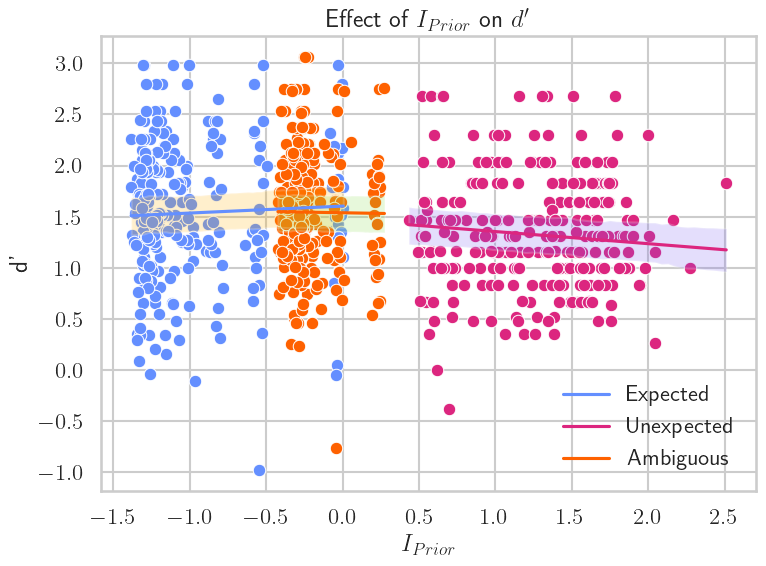

In [134]:
x_grid_expected = np.linspace(df.x_neglog_prior_z[x_condition==0].min(), df.x_neglog_prior_z[x_condition==0].max())
x_grid_unexpected = np.linspace(df.x_neglog_prior_z[x_condition==2].min(), df.x_neglog_prior_z[x_condition==2].max())
x_grid_ambiguous = np.linspace(df.x_neglog_prior_z[x_condition==1].min(), df.x_neglog_prior_z[x_condition==1].max())

alpha = posterior["alpha"].values.reshape(-1)
beta_condition = posterior["beta_condition"].values.reshape(-1)
beta_neglog_prior = posterior["beta_x"].values.reshape(-1)
beta_interaction = posterior["beta_interaction"].values.reshape(-1)


def predicted_mu(condition_value, grid):
    return (
        alpha[:, None]
        + beta_condition[:, None] * condition_value
        + beta_neglog_prior[:, None] * grid[None, :]
        + beta_interaction[:, None] * condition_value * grid[None, :]
    )

mu_exp = predicted_mu(cond_exp, x_grid_expected)
mu_une = predicted_mu(cond_une, x_grid_unexpected)
mu_amb = predicted_mu(cond_amb, x_grid_ambiguous)

mean_exp = mu_exp.mean(axis=0)
mean_une = mu_une.mean(axis=0)
mean_amb = mu_amb.mean(axis=0)

hdi_exp = az.hdi(mu_exp, hdi_prob=0.95)
hdi_une = az.hdi(mu_une, hdi_prob=0.95)
hdi_amb = az.hdi(mu_amb, hdi_prob=0.95)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=df.x_neglog_prior_z[df.x_condition == 0],
    y=df.y[df.x_condition == 0],
)
sns.scatterplot(
    x=df.x_neglog_prior_z[df.x_condition == 2],
    y=df.y[df.x_condition == 2],
)
sns.scatterplot(
    x=df.x_neglog_prior_z[df.x_condition == 1],
    y=df.y[df.x_condition == 1],
)

plt.plot(x_grid_expected, mean_exp, label="Expected")
plt.fill_between(x_grid_expected, hdi_exp[:, 0], hdi_exp[:, 1], alpha=0.2)

plt.plot(x_grid_unexpected, mean_une, label="Unexpected")
plt.fill_between(x_grid_unexpected, hdi_une[:, 0], hdi_une[:, 1], alpha=0.2)

plt.plot(x_grid_ambiguous, mean_amb, label="Ambiguous")
plt.fill_between(x_grid_ambiguous, hdi_amb[:, 0], hdi_amb[:, 1], alpha=0.2)

plt.xlabel("$I_{Prior}$")
plt.ylabel("d'")
plt.legend(frameon=False, loc="lower right")

plt.title("Effect of $I_{Prior}$ on $d'$")
plt.tight_layout()
plt.savefig("./figures/bayesian_regression_experiment2_dprime.png", dpi=300)
plt.show()

In [135]:
exclusions_experiment2_hotfix = np.array([ 9, 10, 20, 22, 27])
all_acc_exp_experiment2 = np.array(data_store['behavioral_experiment2']['all_acc_exp_experiment2'])
all_acc_exp_experiment2 = np.delete(all_acc_exp_experiment2, exclusions_experiment2_hotfix)
print(np.array(all_acc_exp_experiment2).shape)
all_acc_une_experiment2 = np.array(data_store['behavioral_experiment2']['all_acc_une_experiment2'])
all_acc_une_experiment2 = np.delete(all_acc_une_experiment2, exclusions_experiment2_hotfix)
print(np.array(all_acc_une_experiment2).shape)
all_acc_amb_experiment2 = np.array(data_store['behavioral_experiment2']['all_acc_amb_experiment2'])
all_acc_amb_experiment2 = np.delete(all_acc_amb_experiment2, exclusions_experiment2_hotfix)
print(np.array(all_acc_amb_experiment2).shape)

all_rt_exp_experiment2_blockwise = data_store['behavioral_experiment2']['all_rt_exp_experiment2_blockwise']
print(np.array(list(all_rt_exp_experiment2_blockwise.values())).shape)
all_rt_une_experiment2_blockwise = data_store['behavioral_experiment2']['all_rt_une_experiment2_blockwise']
print(np.array(list(all_rt_une_experiment2_blockwise.values())).shape)
all_rt_amb_experiment2_blockwise = data_store['behavioral_experiment2']['all_rt_amb_experiment2_blockwise']
print(np.array(list(all_rt_amb_experiment2_blockwise.values())).shape)

all_acc_exp_model = data_store['model_experiment2']['all_acc_exp_experiment2']
print(np.array(all_acc_exp_model).shape)
all_acc_une_model = data_store['model_experiment2']['all_acc_une_experiment2']
print(np.array(all_acc_une_model).shape)
all_acc_amb_model = data_store['model_experiment2']['all_acc_amb_experiment2']
print(np.array(all_acc_amb_model).shape)

all_surprize_exp_model_blockwise = data_store['model_experiment2']['all_surprize_exp_model_blockwise']
print(np.array(list(all_surprize_exp_model_blockwise.values())).shape)
all_surprize_une_model_blockwise = data_store['model_experiment2']['all_surprize_une_model_blockwise']
print(np.array(list(all_surprize_une_model_blockwise.values())).shape)
all_surprize_amb_model_blockwise = data_store['model_experiment2']['all_surprize_amb_model_blockwise']
print(np.array(list(all_surprize_amb_model_blockwise.values())).shape)


(25,)
(25,)
(25,)
(11, 25)
(11, 25)
(11, 25)
(25,)
(25,)
(25,)
(11, 25)
(11, 25)
(11, 25)


/tmp/ipykernel_3960657/828959002.py:153: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_exp = az.hdi(mu_exp, hdi_prob=0.95)
/tmp/ipykernel_3960657/828959002.py:154: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_une = az.hdi(mu_une, hdi_prob=0.95)
/tmp/ipykernel_3960657/828959002.py:155: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_amb = az.hdi(mu_amb, hdi_prob=0.95)


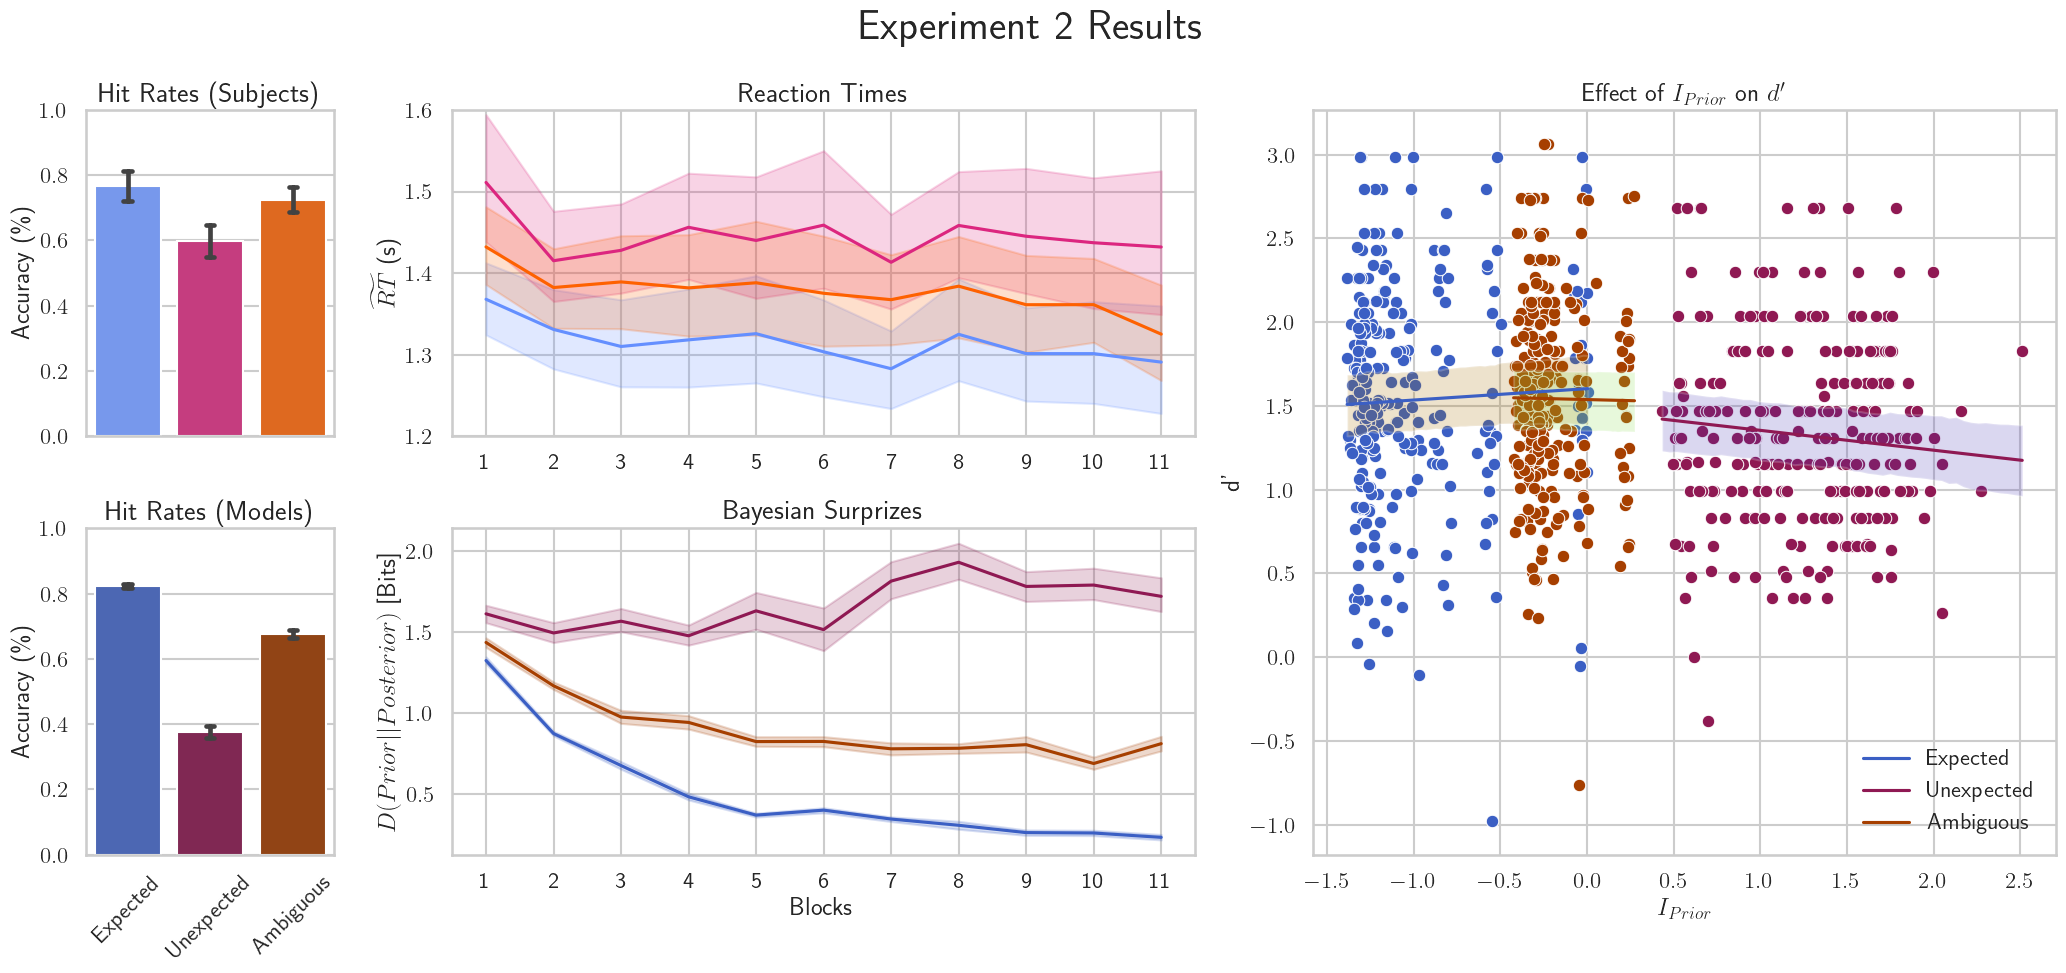

In [137]:
# plot next to other results
# with open("./stats/data_store_with_hitrates.pkl", "rb") as f:
#     data_store = pkl.load(f)
# print(data_store.keys())


ibm_palette = ["#648fff", "#dc267f", "#fe6100", "#ffb000", "#785ef0", "#8be04e", "#009e73", "#56b4e9",]
ibm_palette_darker = ["#3b5fc4", "#8f1953", "#a63f00", "#a86f00", "#4a37b8", "#8be04e", "#009e73", "#56b4e9",]


fig = plt.figure(figsize=(21, 10))
gs = fig.add_gridspec(2, 3, width_ratios=[1, 3, 3], height_ratios=[1, 1])
ax0 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

sns.set_palette(ibm_palette)
df_results = pd.DataFrame(
    np.array([all_acc_exp_experiment2, all_acc_une_experiment2, all_acc_amb_experiment2]).T,
    columns=["Expected", "Unexpected", 'Ambiguous'],
)
sns.barplot(df_results, ax=ax0, errorbar=("ci", 95), capsize=0.1)  # 95% confience interval
ax0.set_title("Hit Rates (Subjects)", fontweight="bold", fontsize=20)
ax0.set_ylabel(r"Accuracy (\%)")
ax0.set_ylim(0, 1)
ax0.set_xticks([])


# rts/surprizes
sns.set_palette(ibm_palette)
sns.lineplot(
    data=(
        pd.DataFrame(all_rt_exp_experiment2_blockwise)
        .T.assign(x=np.arange(len(all_rt_exp_experiment2_blockwise)))
        .melt(id_vars="x", value_name="y")
    ),
    x="x",
    y="y",
    errorbar=("ci", 95),
    ax=ax2,
)
sns.lineplot(
    data=(
        pd.DataFrame(all_rt_une_experiment2_blockwise)
        .T.assign(x=np.arange(len(all_rt_une_experiment2_blockwise)))
        .melt(id_vars="x", value_name="y")
    ),
    x="x",
    y="y",
    errorbar=("ci", 95),
    ax=ax2,
)
sns.lineplot(
    data=(
        pd.DataFrame(all_rt_amb_experiment2_blockwise)
        .T.assign(x=np.arange(len(all_rt_amb_experiment2_blockwise)))
        .melt(id_vars="x", value_name="y")
    ),
    x="x",
    y="y",
    errorbar=("ci", 95),
    ax=ax2,
)
ax2.set_title(r"Reaction Times", fontweight="bold", fontsize=20)
ax2.set_ylabel(r"$\widetilde{RT}$ (s)")
ax2.set_ylim(1.2, 1.6)
ax2.set_xlabel("")
ax2.set_xticks(range(11), np.arange(1, 12))


sns.set_palette(ibm_palette_darker)
ax1 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

df_results = pd.DataFrame(
    np.array([all_acc_exp_model, all_acc_une_model, all_acc_amb_model]).T,
    columns=["Expected", "Unexpected", 'Ambiguous'],
)
sns.barplot(df_results, ax=ax1, errorbar=("ci", 95), capsize=0.1)  # 95% confience interval
ax1.set_title("Hit Rates (Models)", fontweight="bold", fontsize=20)
ax1.set_ylabel(r"Accuracy (\%)")
ax1.set_ylim(0, 1)
ax1.tick_params(axis="x", rotation=45)

sns.set_palette(ibm_palette_darker)
sns.lineplot(
    data=(
        pd.DataFrame(all_surprize_exp_model_blockwise)
        .T.assign(x=np.arange(len(all_surprize_exp_model_blockwise)))
        .melt(id_vars="x", value_name="y")
    ),
    x="x",
    y="y",
    errorbar=("ci", 95),
    ax=ax3,
)
sns.lineplot(
    data=(
        pd.DataFrame(all_surprize_une_model_blockwise)
        .T.assign(x=np.arange(len(all_surprize_une_model_blockwise)))
        .melt(id_vars="x", value_name="y")
    ),
    x="x",
    y="y",
    errorbar=("ci", 95),
    ax=ax3,
)
sns.lineplot(
    data=(
        pd.DataFrame(all_surprize_amb_model_blockwise)
        .T.assign(x=np.arange(len(all_surprize_amb_model_blockwise)))
        .melt(id_vars="x", value_name="y")
    ),
    x="x",
    y="y",
    errorbar=("ci", 95),
    ax=ax3,
)

ax3.set_title(r"Bayesian Surprizes", fontweight="bold", fontsize=20)
ax3.set_ylabel(r"$D(Prior||Posterior)$ [Bits]")
# ax3.set_ylim(1.2, 1.6)
ax3.set_xlabel("Blocks")
ax3.set_xticks(range(11), np.arange(1, 12))

ax4 = fig.add_subplot(gs[:, 2:])

x_grid_expected = np.linspace(df.x_neglog_prior_z[x_condition==0].min(), df.x_neglog_prior_z[x_condition==0].max())
x_grid_unexpected = np.linspace(df.x_neglog_prior_z[x_condition==2].min(), df.x_neglog_prior_z[x_condition==2].max())
x_grid_ambiguous = np.linspace(df.x_neglog_prior_z[x_condition==1].min(), df.x_neglog_prior_z[x_condition==1].max())

alpha = posterior["alpha"].values.reshape(-1)
beta_condition = posterior["beta_condition"].values.reshape(-1)
beta_neglog_prior = posterior["beta_x"].values.reshape(-1)
beta_interaction = posterior["beta_interaction"].values.reshape(-1)


def predicted_mu(condition_value, grid):
    return (
        alpha[:, None]
        + beta_condition[:, None] * condition_value
        + beta_neglog_prior[:, None] * grid[None, :]
        + beta_interaction[:, None] * condition_value * grid[None, :]
    )

mu_exp = predicted_mu(cond_exp, x_grid_expected)
mu_une = predicted_mu(cond_une, x_grid_unexpected)
mu_amb = predicted_mu(cond_amb, x_grid_ambiguous)

mean_exp = mu_exp.mean(axis=0)
mean_une = mu_une.mean(axis=0)
mean_amb = mu_amb.mean(axis=0)

hdi_exp = az.hdi(mu_exp, hdi_prob=0.95)
hdi_une = az.hdi(mu_une, hdi_prob=0.95)
hdi_amb = az.hdi(mu_amb, hdi_prob=0.95)

# plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=df.x_neglog_prior_z[df.x_condition == 0],
    y=df.y[df.x_condition == 0],
    ax=ax4
)
sns.scatterplot(
    x=df.x_neglog_prior_z[df.x_condition == 2],
    y=df.y[df.x_condition == 2],
    ax=ax4
)
sns.scatterplot(
    x=df.x_neglog_prior_z[df.x_condition == 1],
    y=df.y[df.x_condition == 1],
    ax=ax4
)

ax4.plot(x_grid_expected, mean_exp, label="Expected")
ax4.fill_between(x_grid_expected, hdi_exp[:, 0], hdi_exp[:, 1], alpha=0.2)

ax4.plot(x_grid_unexpected, mean_une, label="Unexpected")
ax4.fill_between(x_grid_unexpected, hdi_une[:, 0], hdi_une[:, 1], alpha=0.2)

ax4.plot(x_grid_ambiguous, mean_amb, label="Ambiguous")
ax4.fill_between(x_grid_ambiguous, hdi_amb[:, 0], hdi_amb[:, 1], alpha=0.2)

ax4.set_xlabel("$I_{Prior}$")
ax4.set_ylabel("d'")
ax4.legend(frameon=False, loc="lower right")
ax4.set_title("Effect of $I_{Prior}$ on $d'$")

plt.suptitle("Experiment 2 Results", fontweight="bold", fontsize=30)
plt.tight_layout()
plt.savefig("./behavioral_modeling_results/all_results_experiment2.png", dpi=300)

plt.show()

# reset
sns.set_palette(ibm_palette)

In [145]:
all_acc_exp_experiment2 = np.array(data_store['behavioral_experiment2']['all_acc_exp_experiment2'])
all_acc_exp_experiment2 = np.delete(all_acc_exp_experiment2, exclusions_experiment2_hotfix)
all_acc_une_experiment2 = np.array(data_store['behavioral_experiment2']['all_acc_une_experiment2'])
all_acc_une_experiment2 = np.delete(all_acc_une_experiment2, exclusions_experiment2_hotfix)
all_acc_amb_experiment2 = np.array(data_store['behavioral_experiment2']['all_acc_amb_experiment2'])
all_acc_amb_experiment2 = np.delete(all_acc_amb_experiment2, exclusions_experiment2_hotfix)
print(all_acc_amb_experiment2.shape)

all_rt_exp_experiment2_blockwise = np.nanmean(list(data_store['behavioral_experiment2']['all_rt_exp_experiment2_blockwise'].values()), axis=0)
all_rt_une_experiment2_blockwise = np.nanmean(list(data_store['behavioral_experiment2']['all_rt_une_experiment2_blockwise'].values()), axis=0)
all_rt_amb_experiment2_blockwise = np.nanmean(list(data_store['behavioral_experiment2']['all_rt_amb_experiment2_blockwise'].values()), axis=0)
print(all_rt_amb_experiment2_blockwise.shape)

all_acc_exp_model = np.array(data_store['model_experiment2']['all_acc_exp_experiment2'])
all_acc_une_model = np.array(data_store['model_experiment2']['all_acc_une_experiment2'])
all_acc_amb_model = np.array(data_store['model_experiment2']['all_acc_amb_experiment2'])
print(all_acc_amb_model.shape)

all_surprize_exp_model_blockwise = np.nanmean(list(data_store['model_experiment2']['all_surprize_exp_model_blockwise'].values()), axis=0)
all_surprize_une_model_blockwise = np.nanmean(list(data_store['model_experiment2']['all_surprize_une_model_blockwise'].values()), axis=0)
all_surprize_amb_model_blockwise = np.nanmean(list(data_store['model_experiment2']['all_surprize_amb_model_blockwise'].values()), axis=0)
print(all_surprize_amb_model_blockwise.shape)


(25,)
(25,)
(25,)
(25,)


In [170]:
print('hit rates subjects')
print('Experiment2, exp:', 'mean:', np.round(100*np.mean(all_acc_exp_experiment2),2), '\\%, \\% CI:', seaborn_exact_ci(all_acc_exp_experiment2), '\\%')
print('Experiment2, une:', 'mean:', np.round(100*np.mean(all_acc_une_experiment2),2), '\\%, \\% CI:', seaborn_exact_ci(all_acc_une_experiment2), '\\%')
print('Experiment2, amb:', 'mean:', np.round(100*np.mean(all_acc_amb_experiment2),2), '\\%, \\% CI:', seaborn_exact_ci(all_acc_amb_experiment2), '\\%')
print('hit rates models')
print('Experiment2, exp:', 'mean:', np.round(100*np.mean(all_acc_exp_model),2), '\\%, \\% CI:', seaborn_exact_ci(all_acc_exp_model), '\\%')
print('Experiment2, une:', 'mean:', np.round(100*np.mean(all_acc_une_model),2), '\\%, \\% CI:', seaborn_exact_ci(all_acc_une_model), '\\%')
print('Experiment2, amb:', 'mean:', np.round(100*np.mean(all_acc_amb_model),2), '\\%, \\% CI:', seaborn_exact_ci(all_acc_amb_model), '\\%')
print('RTs')
print('Experiment2, exp:', 'mean:', np.round(np.mean(all_rt_exp_experiment2_blockwise),2), '\\% CI:', seaborn_exact_ci(all_rt_exp_experiment2_blockwise, times=1))
print('Experiment2, une:', 'mean:', np.round(np.mean(all_rt_une_experiment2_blockwise),2), '\\% CI:', seaborn_exact_ci(all_rt_une_experiment2_blockwise, times=1))
print('Experiment2, amb:', 'mean:', np.round(np.mean(all_rt_amb_experiment2_blockwise),2), '\\% CI:', seaborn_exact_ci(all_rt_amb_experiment2_blockwise, times=1))
print('KL')
print('Experiment2, exp:', 'mean:', np.round(np.mean(all_surprize_exp_model_blockwise),2), '\\% CI:', seaborn_exact_ci(all_surprize_exp_model_blockwise, times=1))
print('Experiment2, une:', 'mean:', np.round(np.mean(all_surprize_une_model_blockwise),2), '\\% CI:', seaborn_exact_ci(all_surprize_une_model_blockwise, times=1))
print('Experiment2, amb:', 'mean:', np.round(np.mean(all_surprize_amb_model_blockwise),2), '\\% CI:', seaborn_exact_ci(all_surprize_amb_model_blockwise, times=1))


hit rates subjects
Experiment2, exp: mean: 76.82 \%, \% CI: [72.21 81.29] \%
Experiment2, une: mean: 59.74 \%, \% CI: [54.97 64.87] \%
Experiment2, amb: mean: 72.42 \%, \% CI: [68.39 76.46] \%
hit rates models
Experiment2, exp: mean: 82.24 \%, \% CI: [81.69 82.87] \%
Experiment2, une: mean: 37.59 \%, \% CI: [35.82 39.44] \%
Experiment2, amb: mean: 67.6 \%, \% CI: [66.46 68.72] \%
RTs
Experiment2, exp: mean: 1.31 \% CI: [1.27 1.36]
Experiment2, une: mean: 1.45 \% CI: [1.39 1.5 ]
Experiment2, amb: mean: 1.38 \% CI: [1.33 1.43]
KL
Experiment2, exp: mean: 0.5 \% CI: [0.5  0.51]
Experiment2, une: mean: 1.67 \% CI: [1.64 1.69]
Experiment2, amb: mean: 0.91 \% CI: [0.9  0.92]


In [165]:
# subject hit rates

df_long = pd.DataFrame(
    {
        "subject_id": np.tile(range(len(all_acc_exp_experiment2)), 3),
        "condition": np.repeat(["exp", "une", "amb"], len(all_acc_exp_experiment2)),
        "hit_rate": np.concatenate([all_acc_exp_experiment2, all_acc_une_experiment2, all_acc_amb_experiment2]),
    }
)
anova = pg.rm_anova(
    data=df_long,
    dv="hit_rate",
    within="condition",
    subject="subject_id",
    detailed=True,
)
display(anova)

posthocs = pg.pairwise_tests(
    data=df_long,
    dv="hit_rate",
    within="condition",
    subject="subject_id",
    padjust="holm",  # 'bonf' or 'holm'
    effsize="hedges",  # Calculates Hedges' g for each pair
)
display(
    posthocs[["A", "B", "T", "dof", "p-unc", "p-corr", "p-adjust", "hedges"]]
)

,Source,SS,DF,MS,F,p-unc,ng2,eps
0,condition,0.393189,2,0.196595,35.180808,3.914970e-10,0.277598,0.590556
1,Error,0.268230,48,0.005588,NaN,NaN,NaN,NaN


,A,B,T,dof,p-unc,p-corr,p-adjust,hedges
0,amb,exp,-3.616485,24.0,0.001380,0.001380,holm,-0.385233
1,amb,une,6.307624,24.0,0.000002,0.000005,holm,1.043246
2,exp,une,6.081565,24.0,0.000003,0.000006,holm,1.343857


In [166]:
# model hit rates

df_long = pd.DataFrame(
    {
        "subject_id": np.tile(range(len(all_acc_exp_model)), 3),
        "condition": np.repeat(["exp", "une", "amb"], len(all_acc_exp_model)),
        "hit_rate": np.concatenate([all_acc_exp_model, all_acc_une_model, all_acc_amb_model]),
    }
)
anova = pg.rm_anova(
    data=df_long,
    dv="hit_rate",
    within="condition",
    subject="subject_id",
    detailed=True,
)
display(anova)

posthocs = pg.pairwise_tests(
    data=df_long,
    dv="hit_rate",
    within="condition",
    subject="subject_id",
    padjust="holm",  # 'bonf' or 'holm'
    effsize="hedges",  # Calculates Hedges' g for each pair
)
display(
    posthocs[["A", "B", "T", "dof", "p-unc", "p-corr", "p-adjust", "hedges"]]
)

,Source,SS,DF,MS,F,p-unc,ng2,eps
0,condition,2.590763,2,1.295382,1367.575562,4.796305e-43,0.969676,0.731346
1,Error,0.045466,48,0.000947,NaN,NaN,NaN,NaN


,A,B,T,dof,p-unc,p-corr,p-adjust,hedges
0,amb,exp,-23.975091,24.0,2.822339e-18,2.822339e-18,holm,-6.038443
1,amb,une,27.770076,24.0,9.341501e-20,1.868300e-19,holm,7.463140
2,exp,une,52.174327,24.0,3.212882e-26,9.638647e-26,holm,12.483846


In [167]:
# subject rts

df_long = pd.DataFrame(
    {
        "subject_id": np.tile(range(len(all_rt_exp_experiment2_blockwise)), 3),
        "condition": np.repeat(["exp", "une", "amb"], len(all_rt_exp_experiment2_blockwise)),
        "hit_rate": np.concatenate([all_rt_exp_experiment2_blockwise, all_rt_une_experiment2_blockwise, all_rt_amb_experiment2_blockwise]),
    }
)
anova = pg.rm_anova(
    data=df_long,
    dv="hit_rate",
    within="condition",
    subject="subject_id",
    detailed=True,
)
display(anova)

posthocs = pg.pairwise_tests(
    data=df_long,
    dv="hit_rate",
    within="condition",
    subject="subject_id",
    padjust="holm",  # 'bonf' or 'holm'
    effsize="hedges",  # Calculates Hedges' g for each pair
)
display(
    posthocs[["A", "B", "T", "dof", "p-unc", "p-corr", "p-adjust", "hedges"]]
)

,Source,SS,DF,MS,F,p-unc,ng2,eps
0,condition,0.214819,2,0.107409,39.230627,7.994846e-11,0.139264,0.58467
1,Error,0.131419,48,0.002738,NaN,NaN,NaN,NaN


,A,B,T,dof,p-unc,p-corr,p-adjust,hedges
0,amb,exp,5.577992,24.0,9.699570e-06,0.000010,holm,0.469068
1,amb,une,-6.064127,24.0,2.910848e-06,0.000006,holm,-0.482942
2,exp,une,-6.523218,24.0,9.550203e-07,0.000003,holm,-0.945790


In [168]:
# KLs

df_long = pd.DataFrame(
    {
        "subject_id": np.tile(range(len(all_surprize_exp_model_blockwise)), 3),
        "condition": np.repeat(["exp", "une", "amb"], len(all_surprize_exp_model_blockwise)),
        "hit_rate": np.concatenate([all_surprize_exp_model_blockwise, all_surprize_une_model_blockwise, all_surprize_amb_model_blockwise]),
    }
)
anova = pg.rm_anova(
    data=df_long,
    dv="hit_rate",
    within="condition",
    subject="subject_id",
    detailed=True,
)
display(anova)

posthocs = pg.pairwise_tests(
    data=df_long,
    dv="hit_rate",
    within="condition",
    subject="subject_id",
    padjust="holm",  # 'bonf' or 'holm'
    effsize="hedges",  # Calculates Hedges' g for each pair
)
display(
    posthocs[["A", "B", "T", "dof", "p-unc", "p-corr", "p-adjust", "hedges"]]
)

,Source,SS,DF,MS,F,p-unc,ng2,eps
0,condition,17.522339,2,8.761169,4418.691404,3.815595e-55,0.992816,0.661237
1,Error,0.095172,48,0.001983,NaN,NaN,NaN,NaN


,A,B,T,dof,p-unc,p-corr,p-adjust,hedges
0,amb,exp,58.076673,24.0,2.501927e-27,5.003854e-27,holm,16.183388
1,amb,une,-48.716820,24.0,1.641089e-25,1.641089e-25,holm,-14.794320
2,exp,une,-85.868282,24.0,2.195714e-31,6.587141e-31,holm,-24.910901


# Highest ranked model (Bayesian Surprise)

In [171]:
print("bayesian_surprize")
with pm.Model() as model:
    alpha = pm.Normal("alpha", 0, 1)
    sigma_participant = pm.HalfNormal("sigma_participant", 1)
    a_participant = pm.Normal(
        "a_participant", 0, sigma_participant, shape=n_participants
    )
    beta_x = pm.Normal("beta_x", 0, 1)
    beta_condition = pm.Normal("beta_condition", 0, 1)
    beta_interaction = pm.Normal("beta_interaction", 0, 1)
    mu = (
        alpha
        + a_participant[participant_idx]
        + beta_condition * x_condition
        + beta_x * x_bayesian_surprize
        + beta_interaction * x_condition * x_bayesian_surprize
    )
    sigma = pm.HalfNormal("sigma", 1)
    pm.Normal("y", mu=mu, sigma=sigma, observed=y)
    idata_x_bayesian_surprize = pm.sample(
        target_accept=0.95,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True},
        random_seed=seed,
    )
df_summary = az.summary(
    idata_x_bayesian_surprize,
    var_names=[
        "alpha",
        "beta_x",
        "beta_condition",
        "beta_interaction",
        "sigma",
        "sigma_participant",
    ],
    hdi_prob=0.95,
)

display(df_summary)
df_summary.to_latex(
    # "model_comparison.tex",
    float_format="%.3f",
    caption="Regression Coefficients of Winning Model",
    label="tab:winner_model",
)

bayesian_surprize


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, sigma_participant, a_participant, beta_x, beta_condition, beta_interaction, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.593,0.092,1.406,1.766,0.004,0.003,597.0,775.0,1.01
beta_x,0.056,0.041,-0.022,0.136,0.001,0.001,3219.0,3031.0,1.00
beta_condition,-0.057,0.039,-0.128,0.023,0.001,0.001,3984.0,2917.0,1.00
beta_interaction,-0.093,0.024,-0.141,-0.047,0.000,0.000,3908.0,2993.0,1.00
sigma,0.469,0.012,0.445,0.492,0.000,0.000,3801.0,2598.0,1.00
sigma_participant,0.388,0.062,0.276,0.511,0.001,0.001,3942.0,2544.0,1.00


'\\begin{table}\n\\caption{Regression Coefficients of Winning Model}\n\\label{tab:winner_model}\n\\begin{tabular}{lrrrrrrrrr}\n\\toprule\n & mean & sd & hdi_2.5% & hdi_97.5% & mcse_mean & mcse_sd & ess_bulk & ess_tail & r_hat \\\\\n\\midrule\nalpha & 1.593 & 0.092 & 1.406 & 1.766 & 0.004 & 0.003 & 597.000 & 775.000 & 1.010 \\\\\nbeta_x & 0.056 & 0.041 & -0.022 & 0.136 & 0.001 & 0.001 & 3219.000 & 3031.000 & 1.000 \\\\\nbeta_condition & -0.057 & 0.039 & -0.128 & 0.023 & 0.001 & 0.001 & 3984.000 & 2917.000 & 1.000 \\\\\nbeta_interaction & -0.093 & 0.024 & -0.141 & -0.047 & 0.000 & 0.000 & 3908.000 & 2993.000 & 1.000 \\\\\nsigma & 0.469 & 0.012 & 0.445 & 0.492 & 0.000 & 0.000 & 3801.000 & 2598.000 & 1.000 \\\\\nsigma_participant & 0.388 & 0.062 & 0.276 & 0.511 & 0.001 & 0.001 & 3942.000 & 2544.000 & 1.000 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

# Does I_prior epxlain beyond condition?

In [172]:
# baseline model

with pm.Model() as model:
    alpha = pm.Normal("alpha", 0, 1)
    sigma_participant = pm.HalfNormal("sigma_participant", 1)
    a_participant = pm.Normal(
        "a_participant", 0, sigma_participant, shape=n_participants
    )
    beta_condition = pm.Normal("beta_condition", 0, 1)
    mu = (
        alpha
        + a_participant[participant_idx]
        + beta_condition * x_condition
    )
    sigma = pm.HalfNormal("sigma", 1)
    pm.Normal("y", mu=mu, sigma=sigma, observed=y)
    idata_condition = pm.sample(
        target_accept=0.95,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True},
        random_seed=seed,
    )
df_results = az.summary(
    idata_condition,
    var_names=[
        "alpha",
        "beta_condition",
        "sigma",
        "sigma_participant",
    ],
    hdi_prob=0.95,
)
display(df_results)

df_results.to_latex(
    # "model_comparison.tex",
    float_format="%.3f",
    caption="LOO model comparison",
    label="tab:model_comparison",
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, sigma_participant, a_participant, beta_condition, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.589,0.086,1.430,1.772,0.005,0.003,284.0,488.0,1.01
beta_condition,-0.105,0.020,-0.144,-0.066,0.000,0.000,2832.0,2779.0,1.00
sigma,0.473,0.012,0.452,0.497,0.000,0.000,2683.0,2188.0,1.00
sigma_participant,0.391,0.064,0.277,0.521,0.001,0.001,2162.0,2208.0,1.00


'\\begin{table}\n\\caption{LOO model comparison}\n\\label{tab:model_comparison}\n\\begin{tabular}{lrrrrrrrrr}\n\\toprule\n & mean & sd & hdi_2.5% & hdi_97.5% & mcse_mean & mcse_sd & ess_bulk & ess_tail & r_hat \\\\\n\\midrule\nalpha & 1.589 & 0.086 & 1.430 & 1.772 & 0.005 & 0.003 & 284.000 & 488.000 & 1.010 \\\\\nbeta_condition & -0.105 & 0.020 & -0.144 & -0.066 & 0.000 & 0.000 & 2832.000 & 2779.000 & 1.000 \\\\\nsigma & 0.473 & 0.012 & 0.452 & 0.497 & 0.000 & 0.000 & 2683.000 & 2188.000 & 1.000 \\\\\nsigma_participant & 0.391 & 0.064 & 0.277 & 0.521 & 0.001 & 0.001 & 2162.000 & 2208.000 & 1.000 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

In [173]:
compare_df = az.compare({'I_prior': idata_x_neglog_prior, 'condition': idata_condition}, ic="loo")
display(compare_df)
compare_df.to_latex(
    # "model_comparison.tex",
    float_format="%.3f",
    caption="LOO model comparison",
    label="tab:model_comparison",
)

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
I_prior,0,-557.184157,28.754990,0.000000,0.918601,31.375319,0.000000,False,log
condition,1,-563.067484,26.888717,5.883327,0.081399,30.781747,3.717632,False,log


'\\begin{table}\n\\caption{LOO model comparison}\n\\label{tab:model_comparison}\n\\begin{tabular}{lrrrrrrrrl}\n\\toprule\n & rank & elpd_loo & p_loo & elpd_diff & weight & se & dse & warning & scale \\\\\n\\midrule\nI_prior & 0 & -557.184 & 28.755 & 0.000 & 0.919 & 31.375 & 0.000 & False & log \\\\\ncondition & 1 & -563.067 & 26.889 & 5.883 & 0.081 & 30.782 & 3.718 & False & log \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

---
# RT

In [44]:
n_participants = 25

df = pd.DataFrame(
    {
        "participant": np.tile(np.arange(n_participants), 11 * 3),
        "x_block": np.concatenate(
            [
                np.repeat(np.arange(11), n_participants),
                np.repeat(np.arange(11), n_participants),
                np.repeat(np.arange(11), n_participants),
            ]
        ),
        "x_condition": np.concatenate(
            [
                np.repeat([0], n_participants * 11),
                np.repeat([2], n_participants * 11),
                np.repeat([1], n_participants * 11),
            ]
        ),
        "x_bayesian_surprize": np.concatenate(
            [
                model_experiment2_surprize_exp.ravel(),
                model_experiment2_surprize_une.ravel(),
                model_experiment2_surprize_amb.ravel(),
            ]
        ),
        "x_log_ratio": np.concatenate(
            [
                model_experiment2_exp_log_ratio.ravel(),
                model_experiment2_une_log_ratio.ravel(),
                model_experiment2_amb_log_ratio.ravel(),
            ]
        ),
        "x_neglog_prior": np.concatenate(
            [
                all_nlprior_exp_model_blockwise.ravel(),
                all_nlprior_une_model_blockwise.ravel(),
                all_nlprior_amb_model_blockwise.ravel(),
            ]
        ),
        "x_neglog_posterior": np.concatenate(
            [
                all_nlposterior_exp_model_blockwise.ravel(),
                all_nlposterior_une_model_blockwise.ravel(),
                all_nlposterior_amb_model_blockwise.ravel(),
            ]
        ),
        "x_H_posterior": np.concatenate(
            [
                model_experiment2_exp_entropies.ravel(),
                model_experiment2_une_entropies.ravel(),
                model_experiment2_amb_entropies.ravel(),
            ]
        ),
        "y": np.concatenate(
            [
                behavioral_experiment2_rt_exp.ravel(),
                behavioral_experiment2_rt_une.ravel(),
                behavioral_experiment2_rt_amb.ravel(),
            ]
        ),
    }
)

# dummies = pd.get_dummies(df['x_condition'], prefix='condition', drop_first=True)
# df = pd.concat([df, dummies], axis=1)

print(df.shape)
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(
    subset=[
        "x_condition",
        "x_block",
        "x_bayesian_surprize",
        "x_log_ratio",
        "x_neglog_prior",
        "x_H_posterior",
        "x_neglog_posterior",
        "y",
    ]
)
print(df.shape)

# condition_B = df['condition_B']
# condition_C = df['condition_C']

df["y_z"] = (df["y"] - df["y"].mean()) / df["y"].std()
df["x_block_z"] = (df["x_block"] - df["x_block"].mean()) / df["x_block"].std()
df["x_bayesian_surprize_z"] = (
    df["x_bayesian_surprize"] - df["x_bayesian_surprize"].mean()
) / df["x_bayesian_surprize"].std()
df["x_log_ratio_z"] = (df["x_log_ratio"] - df["x_log_ratio"].mean()) / df[
    "x_log_ratio"
].std()
df["x_neglog_prior_z"] = (df["x_neglog_prior"] - df["x_neglog_prior"].mean()) / df[
    "x_neglog_prior"
].std()
df["x_neglog_posterior_z"] = (
    df["x_neglog_posterior"] - df["x_neglog_posterior"].mean()
) / df["x_neglog_posterior"].std()
df["x_H_posterior_z"] = (df["x_H_posterior"] - df["x_H_posterior"].mean()) / df["x_H_posterior"].std()

participant_idx = df["participant"].to_numpy()
n_participants = df["participant"].nunique()

# z scored
# x_condition = df['x_condition_z'].to_numpy()
x_block = df["x_block_z"].to_numpy()
x_bayesian_surprize = df["x_bayesian_surprize_z"].to_numpy()
x_log_ratio = df["x_log_ratio_z"].to_numpy()
x_neglog_prior = df["x_neglog_prior_z"].to_numpy()
x_neglog_posterior = df["x_neglog_posterior_z"].to_numpy()
x_H_posterior = df["x_H_posterior_z"].to_numpy()
x_condition = df["x_condition"].to_numpy()
y = df["y"].to_numpy()

df.head()

(825, 9)
(817, 9)


,participant,x_block,x_condition,x_bayesian_surprize,x_log_ratio,x_neglog_prior,x_neglog_posterior,x_H_posterior,y,y_z,x_block_z,x_bayesian_surprize_z,x_log_ratio_z,x_neglog_prior_z,x_neglog_posterior_z,x_H_posterior_z
0,0,0,0,1.355976,2.531227,2.082040,0.358420,0.872649,1.205154,-1.015269,-1.582305,0.598431,0.565583,-0.067586,-0.813518,-0.244981
1,1,0,0,1.274788,2.370217,2.119904,0.461243,0.982550,1.259541,-0.696094,-1.582305,0.452935,0.306536,-0.031130,-0.206268,0.358159
2,2,0,0,1.284953,2.169862,2.142062,0.460098,0.985897,1.425718,0.279127,-1.582305,0.471152,-0.015813,-0.009794,-0.213032,0.376530
3,3,0,0,1.352142,2.563266,2.154528,0.377523,0.902115,1.391731,0.079676,-1.582305,0.591560,0.617129,0.002208,-0.700701,-0.083270
4,4,0,0,1.439333,2.824103,2.076384,0.339400,0.832015,1.232711,-0.853546,-1.582305,0.747815,1.036787,-0.073032,-0.925844,-0.467980


In [45]:
predictor_names = ["bayesian surprize", "log ratio", "neglog_prior", "neglog_posterior", "H_posterior"]
predictors = [x_bayesian_surprize, x_log_ratio, x_neglog_prior, x_neglog_posterior, x_H_posterior]
idata_predictors = {}

for predictor_name, x_predictor in zip(predictor_names, predictors):
    print(predictor_name)
    with pm.Model() as model:
        alpha = pm.Normal("alpha", 0, 1)
        sigma_participant = pm.HalfNormal("sigma_participant", 1)
        a_participant = pm.Normal(
            "a_participant", 0, sigma_participant, shape=n_participants
        )
        beta_x = pm.Normal("beta_x", 0, 1)
        beta_condition = pm.Normal("beta_condition", 0, 1)
        beta_interaction = pm.Normal("beta_interaction", 0, 1)
        mu = (
            alpha
            + a_participant[participant_idx]  # subject level intercept
            + beta_condition * x_condition  # condition effect
            + beta_x * x_predictor  # predictor effect
            + beta_interaction * x_condition * x_predictor  # interaction
        )
        sigma = pm.HalfNormal("sigma", 1)
        pm.Normal("y", mu=mu, sigma=sigma, observed=y)
        idata_predictors[predictor_name] = pm.sample(
            target_accept=0.95,
            return_inferencedata=True,
            idata_kwargs={"log_likelihood": True},
            random_seed=seed,
        )
        display(
            az.summary(
                idata_predictors[predictor_name],
                var_names=[
                    "alpha",
                    "beta_x",
                    "beta_condition",
                    "beta_interaction",
                    "sigma",
                    "sigma_participant",
                ],
                hdi_prob=0.95,
            )
        )
        pm.sample_posterior_predictive(
            idata_predictors[predictor_name],
            extend_inferencedata=True,
            random_seed=seed,
        )
        display_results(idata_predictors[predictor_name])

bayesian surprize


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, sigma_participant, a_participant, beta_x, beta_condition, beta_interaction, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.343,0.029,1.285,1.399,0.002,0.001,352.0,577.0,1.01
beta_x,0.034,0.009,0.016,0.052,0.000,0.000,1608.0,1856.0,1.00
beta_condition,0.040,0.008,0.025,0.058,0.000,0.000,2235.0,2145.0,1.00
beta_interaction,-0.009,0.005,-0.021,0.001,0.000,0.000,1863.0,2106.0,1.00
sigma,0.102,0.003,0.097,0.107,0.000,0.000,2631.0,2771.0,1.00
sigma_participant,0.134,0.020,0.096,0.174,0.000,0.000,2180.0,2085.0,1.00


...

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.320,0.030,1.262,1.380,0.002,0.001,189.0,372.0,1.02
beta_x,0.014,0.010,-0.006,0.035,0.000,0.000,1578.0,2026.0,1.00
beta_condition,0.059,0.006,0.048,0.071,0.000,0.000,1983.0,2469.0,1.00
beta_interaction,-0.006,0.006,-0.017,0.005,0.000,0.000,1717.0,2245.0,1.00
sigma,0.103,0.003,0.097,0.108,0.000,0.000,3207.0,2921.0,1.01
sigma_participant,0.135,0.021,0.097,0.175,0.000,0.000,1990.0,2150.0,1.00


Sampling: [y]


Output()

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.320,0.030,1.262,1.380,0.002,0.001,189.0,372.0,1.02
beta_x,0.014,0.010,-0.006,0.035,0.000,0.000,1578.0,2026.0,1.00
beta_condition,0.059,0.006,0.048,0.071,0.000,0.000,1983.0,2469.0,1.00
beta_interaction,-0.006,0.006,-0.017,0.005,0.000,0.000,1717.0,2245.0,1.00
sigma,0.103,0.003,0.097,0.108,0.000,0.000,3207.0,2921.0,1.01
sigma_participant,0.135,0.021,0.097,0.175,0.000,0.000,1990.0,2150.0,1.00


In [46]:
df_summary = az.compare(idata_predictors, ic="loo")

display(df_summary)
df_summary.to_latex(
    # "model_comparison.tex",
    float_format="%.3f",
    caption="Regression Coefficients of Winning Model",
    label="tab:winner_model",
)

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
bayesian surprize,0,693.359823,30.550242,0.000000,7.494832e-01,32.949847,0.000000,False,log
neglog_prior,1,690.247669,30.060344,3.112154,0.000000e+00,33.089426,2.537023,False,log
log ratio,2,688.381315,30.521926,4.978508,2.505168e-01,32.176117,4.627938,False,log
neglog_posterior,3,687.374280,30.469770,5.985544,0.000000e+00,32.422839,4.229634,False,log
H_posterior,4,686.627587,31.144755,6.732236,6.661338e-16,33.228821,4.613413,False,log


'\\begin{table}\n\\caption{Regression Coefficients of Winning Model}\n\\label{tab:winner_model}\n\\begin{tabular}{lrrrrrrrrl}\n\\toprule\n & rank & elpd_loo & p_loo & elpd_diff & weight & se & dse & warning & scale \\\\\n\\midrule\nbayesian surprize & 0 & 693.360 & 30.550 & 0.000 & 0.749 & 32.950 & 0.000 & False & log \\\\\nneglog_prior & 1 & 690.248 & 30.060 & 3.112 & 0.000 & 33.089 & 2.537 & False & log \\\\\nlog ratio & 2 & 688.381 & 30.522 & 4.979 & 0.251 & 32.176 & 4.628 & False & log \\\\\nneglog_posterior & 3 & 687.374 & 30.470 & 5.986 & 0.000 & 32.423 & 4.230 & False & log \\\\\nH_posterior & 4 & 686.628 & 31.145 & 6.732 & 0.000 & 33.229 & 4.613 & False & log \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

In [48]:
for name, idata in idata_predictors.items():
    bpval_overall = (idata.posterior_predictive["y"] > idata.observed_data["y"]).mean().values
    print(f"{name}: Bayesian p-value: {bpval_overall.mean():.2f}")

bayesian surprize: Bayesian p-value: 0.51
log ratio: Bayesian p-value: 0.51
neglog_prior: Bayesian p-value: 0.51
neglog_posterior: Bayesian p-value: 0.51
H_posterior: Bayesian p-value: 0.51


In [72]:
print("bayesian surprize")
with pm.Model() as model:
    alpha = pm.Normal("alpha", 0, 1)
    sigma_participant = pm.HalfNormal("sigma_participant", 1)
    a_participant = pm.Normal(
        "a_participant", 0, sigma_participant, shape=n_participants
    )
    beta_x = pm.Normal("beta_x", 0, 1)
    beta_condition = pm.Normal("beta_condition", 0, 1)
    beta_interaction = pm.Normal("beta_interaction", 0, 1)
    mu = (
        alpha
        + a_participant[participant_idx]  # subject level intercept
        + beta_condition * x_condition  # condition effect
        + beta_x * x_bayesian_surprize  # predictor effect
        + beta_interaction * x_condition * x_bayesian_surprize  # interaction
    )
    sigma = pm.HalfNormal("sigma", 1)
    nu = pm.Exponential("nu_minus_one", 1 / 40) + 1
    pm.StudentT("y", nu=nu, mu=mu, sigma=sigma, observed=np.log(y))
    idata_x_bayesian_surprize = pm.sample(
        target_accept=0.95,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True},
        random_seed=seed,
    )

df_result = az.summary(
    idata_x_bayesian_surprize,
    var_names=[
        "alpha",
        "beta_x",
        "beta_condition",
        "beta_interaction",
        "sigma",
        "sigma_participant",
    ],
    hdi_prob=0.95,
)
display(df_result)

df_result.to_latex(
    # "model_comparison.tex",
    float_format="%.3f",
    caption="LOO model comparison",
    label="tab:model_comparison",
)

bayesian surprize


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, sigma_participant, a_participant, beta_x, beta_condition, beta_interaction, sigma, nu_minus_one]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 11 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.295,0.021,0.254,0.339,0.001,0.001,347.0,409.0,1.01
beta_x,0.031,0.006,0.019,0.042,0.000,0.000,1810.0,2240.0,1.00
beta_condition,0.024,0.005,0.013,0.034,0.000,0.000,2331.0,2756.0,1.00
beta_interaction,-0.011,0.003,-0.018,-0.004,0.000,0.000,2421.0,2695.0,1.00
sigma,0.055,0.003,0.050,0.060,0.000,0.000,2234.0,2446.0,1.00
sigma_participant,0.096,0.015,0.070,0.125,0.000,0.000,2372.0,2230.0,1.00


'\\begin{table}\n\\caption{LOO model comparison}\n\\label{tab:model_comparison}\n\\begin{tabular}{lrrrrrrrrr}\n\\toprule\n & mean & sd & hdi_2.5% & hdi_97.5% & mcse_mean & mcse_sd & ess_bulk & ess_tail & r_hat \\\\\n\\midrule\nalpha & 0.295 & 0.021 & 0.254 & 0.339 & 0.001 & 0.001 & 347.000 & 409.000 & 1.010 \\\\\nbeta_x & 0.031 & 0.006 & 0.019 & 0.042 & 0.000 & 0.000 & 1810.000 & 2240.000 & 1.000 \\\\\nbeta_condition & 0.024 & 0.005 & 0.013 & 0.034 & 0.000 & 0.000 & 2331.000 & 2756.000 & 1.000 \\\\\nbeta_interaction & -0.011 & 0.003 & -0.018 & -0.004 & 0.000 & 0.000 & 2421.000 & 2695.000 & 1.000 \\\\\nsigma & 0.055 & 0.003 & 0.050 & 0.060 & 0.000 & 0.000 & 2234.000 & 2446.000 & 1.000 \\\\\nsigma_participant & 0.096 & 0.015 & 0.070 & 0.125 & 0.000 & 0.000 & 2372.000 & 2230.000 & 1.000 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
expected,0.031,0.006,0.019,0.042,0.0,0.0,1810.0,2240.0,1.0
unexpected,0.008,0.005,-0.002,0.018,0.0,0.0,3602.0,3169.0,1.0
ambiguous,0.020,0.004,0.011,0.028,0.0,0.0,2252.0,2731.0,1.0


/tmp/ipykernel_3115622/1800715309.py:54: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_exp = az.hdi(mu_exp, hdi_prob=0.95)
/tmp/ipykernel_3115622/1800715309.py:55: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_une = az.hdi(mu_une, hdi_prob=0.95)
/tmp/ipykernel_3115622/1800715309.py:56: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_amb = az.hdi(mu_amb, hdi_prob=0.95)


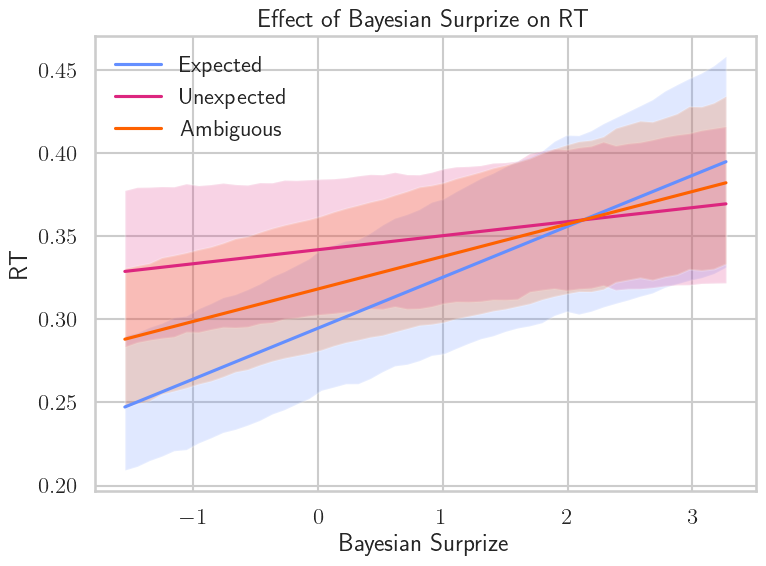

In [73]:
# table
posterior = idata_x_bayesian_surprize.posterior  # .stack(sample=('chain', 'draw'))

cond_exp = 0
cond_une = 2
cond_amb = 1

slope_exp = posterior["beta_x"] + cond_exp * posterior["beta_interaction"]
slope_une = posterior["beta_x"] + cond_une * posterior["beta_interaction"]
slope_amb = posterior["beta_x"] + cond_amb * posterior["beta_interaction"]

df_summary = az.summary(
    {
        "expected": slope_exp,
        "unexpected": slope_une,
        "ambiguous": slope_amb,
    },
    hdi_prob=0.95,
)
display(df_summary)

df_summary.to_latex(
    # "model_comparison.tex",
    float_format="%.3f",
    caption="Simple Effects of Winning Model",
    label="tab:winner_model",
)

x_grid = np.linspace(df.x_bayesian_surprize_z.min(), df.x_bayesian_surprize_z.max())

alpha = posterior["alpha"].values.reshape(-1)
beta_condition = posterior["beta_condition"].values.reshape(-1)
beta_bayesian_surprize = posterior["beta_x"].values.reshape(-1)
beta_interaction = posterior["beta_interaction"].values.reshape(-1)


def predicted_mu(condition_value):
    return (
        alpha[:, None]
        + beta_condition[:, None] * condition_value
        + beta_bayesian_surprize[:, None] * x_grid[None, :]
        + beta_interaction[:, None] * condition_value * x_grid[None, :]
    )


mu_exp = predicted_mu(cond_exp)
mu_une = predicted_mu(cond_une)
mu_amb = predicted_mu(cond_amb)

mean_exp = mu_exp.mean(axis=0)
mean_une = mu_une.mean(axis=0)
mean_amb = mu_amb.mean(axis=0)

hdi_exp = az.hdi(mu_exp, hdi_prob=0.95)
hdi_une = az.hdi(mu_une, hdi_prob=0.95)
hdi_amb = az.hdi(mu_amb, hdi_prob=0.95)

plt.figure(figsize=(8, 6))
plt.plot(x_grid, mean_exp, label="Expected")
plt.fill_between(x_grid, hdi_exp[:, 0], hdi_exp[:, 1], alpha=0.2)

plt.plot(x_grid, mean_une, label="Unexpected")
plt.fill_between(x_grid, hdi_une[:, 0], hdi_une[:, 1], alpha=0.2)

plt.plot(x_grid, mean_amb, label="Ambiguous")
plt.fill_between(x_grid, hdi_amb[:, 0], hdi_amb[:, 1], alpha=0.2)

plt.xlabel("Bayesian Surprize")
plt.ylabel("RT")
plt.legend(frameon=False, loc="upper left")

plt.title("Effect of Bayesian Surprize on RT")
plt.tight_layout()
plt.savefig("./figures/bayesian_regression_experiment2_rt.png", dpi=300)
plt.show()

---